In [1]:
import os
import zipfile
import random
from tqdm import tqdm

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go

import torch
import torch.optim as optim
import torchvision.models as models

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster 
#from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
#from sklearn.cluster import DBSCAN

In [2]:
# загружаем и распаковываем датасет с солнечными пятнами
!wget https://github.com/observethesun/sunspot_groups/raw/main/dataset/sunspot_dataset.zip
!unzip -q sunspot_dataset.zip 

--2025-05-12 11:46:31--  https://github.com/observethesun/sunspot_groups/raw/main/dataset/sunspot_dataset.zip
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/observethesun/sunspot_groups/main/dataset/sunspot_dataset.zip [following]
--2025-05-12 11:46:31--  https://raw.githubusercontent.com/observethesun/sunspot_groups/main/dataset/sunspot_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14406615 (14M) [application/zip]
Saving to: ‘sunspot_dataset.zip’

sunspot_dataset.zip 100%[===================>]  13.74M  --.-KB/s    in 0.06s   

2025-05-12 11:46:32 (226 MB/s) - ‘sunspot_dataset.zip

In [3]:
!pip install -q aiapy
!pip install -q numpydoc
#!pip install -q packaging==21.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 39.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.2/195.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 73.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 3.0 MB/s eta 0:00:00


In [4]:
import git
git.Repo.clone_from('https://github.com/observethesun/helio.git', '/kaggle/working/module_helio')

<git.repo.base.Repo '/kaggle/working/module_helio/.git'>

In [5]:
import sys
sys.path.append('/kaggle/working/module_helio')

from helio import FilesIndex, HelioBatch, BatchSampler
from helio import VAE

2025-05-12 11:47:17.560223: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747050437.797238      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747050437.871073      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [22]:
def transform_channels(arr):
    out = (arr[..., 0] | arr[..., 2]).astype(np.float32)
    out[arr[..., 1]] = 2
    return np.expand_dims(out, 0) / 2 #normalize to [0, 1]
    
itrain = FilesIndex(path='/kaggle/working/sunspot_dataset/*.npz', name='img').sort_index()
itrain.head()

,img
FilesIndex,
201007230452_63,/kaggle/working/sunspot_dataset/201007230452_6...
201007240414_63,/kaggle/working/sunspot_dataset/201007240414_6...
201007250447_63,/kaggle/working/sunspot_dataset/201007250447_6...
201007250447_64,/kaggle/working/sunspot_dataset/201007250447_6...
201007260349_63,/kaggle/working/sunspot_dataset/201007260349_6...


# **Invariants embeddings**

In [7]:
inv_emb = pd.read_csv('/kaggle/input/properties-invariant-embeddings/properties_invariant_embeddings.csv')
df_a = inv_emb .iloc[:,:1]
df_b = inv_emb.iloc[:,17:]
inv_emb = pd.concat([df_a,df_b], axis=1)
inv_emb = inv_emb.set_index('fname').sort_index()
inv_emb.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
fname,,,,,,,,,,,,,,,,,,,,,
201007230452_63,-2.548106,1.181495,1.375547,-0.209886,-0.436301,0.058469,-2.751680,0.625120,1.801969,-0.257077,...,1.324323,0.206686,-0.773984,-0.706433,-2.542088,0.735927,-1.828404,-0.400432,1.794184,3.556576
201007240414_63,3.308705,1.701356,1.008363,-1.859264,2.262855,0.689745,-2.013217,1.596452,1.904591,-0.881336,...,-2.280273,0.033423,0.763244,-1.771013,-2.397232,-2.849603,1.879758,0.610913,2.046473,0.696940
201007250447_63,-1.362825,-0.010082,0.880551,-1.187509,1.229160,0.494770,0.262265,-0.863415,0.337300,-0.723508,...,0.853395,-0.443927,0.792002,0.817088,-1.461736,1.366083,0.501775,0.562915,0.865622,-0.038163
201007250447_64,0.544050,3.871653,-3.011444,1.899010,1.585517,0.991888,0.255717,0.413672,2.141736,0.681359,...,0.882444,-1.093549,-4.075765,-1.007012,-0.632858,-1.608380,3.260197,-3.865491,-2.199181,0.908257
201007260349_63,-0.046227,1.317150,-0.152698,2.753534,0.559023,2.216889,0.822927,1.570466,1.517516,-0.887935,...,-0.926250,-1.676673,-0.953451,-1.084468,-0.894734,-2.140663,0.451901,-0.782241,-1.185347,1.115910


In [8]:
pca = PCA(n_components=2, random_state=0)
inv_emb_pca = pca.fit_transform(inv_emb)

df_inv_emb_pca = pd.DataFrame(inv_emb_pca, columns=['Component 1', 'Component 2'])
df_inv_emb_pca.index = inv_emb.index
df_inv_emb_pca

,Component 1,Component 2
fname,,
201007230452_63,6.722098,-3.372014
201007240414_63,4.168530,-6.150626
201007250447_63,4.547608,-4.136498
201007250447_64,-7.023851,-0.066710
201007260349_63,2.408196,-3.020289
...,...,...
202008120532_31,-6.190829,-1.660586
202008120532_33,-5.304951,-2.274691
202008180351_34,-7.045451,-0.322938


In [9]:
hier_clust = linkage(df_inv_emb_pca, method='ward')
#distances = hier_clust[-15:, 2]
distances = hier_clust[-1000:, 2]
distances_sorted = sorted(distances, reverse=True)

NUM = 13 # порог для разбиения на кластеры (число кластеров)
labels_inv_vae = fcluster(hier_clust, t=distances_sorted[NUM-1], criterion='distance')
#print('Количество полученных кластеров',len(set(labels_inv_vae)))

In [10]:
df_inv_emb_pca['cluster'] = labels_inv_vae
df_inv_emb_pca = df_inv_emb_pca.reset_index()
df_inv_emb_pca

,fname,Component 1,Component 2,cluster
0,201007230452_63,6.722098,-3.372014,6
1,201007240414_63,4.168530,-6.150626,7
2,201007250447_63,4.547608,-4.136498,7
3,201007250447_64,-7.023851,-0.066710,3
4,201007260349_63,2.408196,-3.020289,5
...,...,...,...,...
8493,202008120532_31,-6.190829,-1.660586,2
8494,202008120532_33,-5.304951,-2.274691,2
8495,202008180351_34,-7.045451,-0.322938,3
8496,202008190344_34,2.368722,2.399509,13


# **Классы из Цюрихской обсерватории**

In [6]:
zurich_class = pd.read_csv('/kaggle/input/type-sunspots-zurich/merge_type_sunspots.csv',index_col = 0)

replacement_dict_observe = {None: 'Unknown'}

zurich_class['Type'] = zurich_class['Type'].replace(replacement_dict_observe)
zurich_class = zurich_class[zurich_class['Type'] != 'Unknown']
#zurich_class = zurich_class.set_index('fname')#.sort_index()
print(zurich_class.shape)
zurich_class.head()

(7520, 6)


,fname,Date,Time,Latitude,Longitude,Type
0,201007230452_63,2010-07-23,04:52,-23.565131,200.328655,D
1,201007240414_63,2010-07-24,04:14,-23.933526,201.274268,D
2,201007250447_64,2010-07-25,04:47,23.339903,149.048761,B
3,201007250447_63,2010-07-25,04:47,-23.509269,201.557542,D
4,201007260349_63,2010-07-26,03:49,-23.032369,202.530956,D


# **Сопоставление классов:** 
* полученных с помощью кластеризации
* определенных в обсерватории

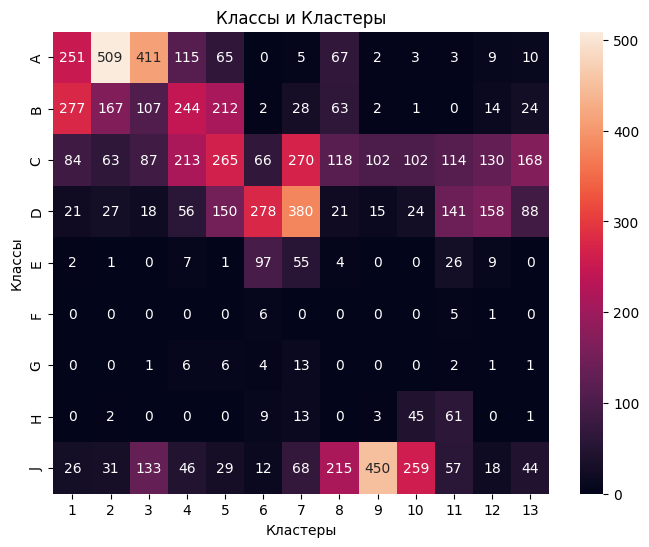

In [11]:
link = pd.merge(zurich_class,df_inv_emb_pca, how='left', on='fname')
link = link[['fname','Date','Time','Latitude','Longitude','Type','cluster']]

crosstab = pd.crosstab(link['Type'], link['cluster'])

plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, fmt='d')
plt.title('Классы и Кластеры')
plt.xlabel('Кластеры')
plt.ylabel('Классы')
plt.show()

In [9]:
crosstab

cluster,1,2,3,4,5,6,7,8,9,10,11,12,13
Type,,,,,,,,,,,,,
A,251,509,411,115,65,0,5,67,2,3,3,9,10
B,277,167,107,244,212,2,28,63,2,1,0,14,24
C,84,63,87,213,265,66,270,118,102,102,114,130,168
D,21,27,18,56,150,278,380,21,15,24,141,158,88
E,2,1,0,7,1,97,55,4,0,0,26,9,0
F,0,0,0,0,0,6,0,0,0,0,5,1,0
G,0,0,1,6,6,4,13,0,0,0,2,1,1
H,0,2,0,0,0,9,13,0,3,45,61,0,1
J,26,31,133,46,29,12,68,215,450,259,57,18,44


# **Оценка принадлежности кластеров классам при условии, что кластер принадлежит одному классу**

In [12]:
max_values = crosstab.max()
max_indices = crosstab.idxmax()
max_col = pd.DataFrame({
    'max_values': max_values,
    'max_indices': max_indices
})
max_col = max_col.sort_values(by=['max_indices', 'max_values'], ascending=[True, False]).reset_index()
max_col

,cluster,max_values,max_indices
0,2,509,A
1,3,411,A
2,1,277,B
3,4,244,B
4,5,265,C
5,13,168,C
6,7,380,D
7,6,278,D
8,12,158,D
9,11,141,D


In [13]:
type_tp = max_col.groupby('max_indices')['max_values'].sum().reset_index(name='sum_max_values')
type_total = crosstab.sum(axis=1).reset_index(name='sum_values')
type_acc = pd.merge(type_total, type_tp, how='left', left_on='Type',right_on='max_indices') 
type_acc.loc[type_acc['max_indices'].isna(), 'sum_max_values'] = 0
type_acc['Accuracy'] = (type_acc['sum_max_values'] / type_acc['sum_values'])
type_acc

,Type,sum_values,max_indices,sum_max_values,Accuracy
0,A,1450,A,920.0,0.634483
1,B,1141,B,521.0,0.456617
2,C,1782,C,433.0,0.242985
3,D,1377,D,957.0,0.694989
4,E,202,NaN,0.0,0.000000
5,F,12,NaN,0.0,0.000000
6,G,34,NaN,0.0,0.000000
7,H,134,NaN,0.0,0.000000
8,J,1388,J,924.0,0.665706


  Type  Accuracy
0    A  0.634483
1    B  0.456617
2    C  0.242985
3    D  0.694989
4    E  0.000000
5    F  0.000000
6    G  0.000000
7    H  0.000000
8    J  0.665706 

Сумма максимальных значений 3755
Accuracy total 0.49933510638297873


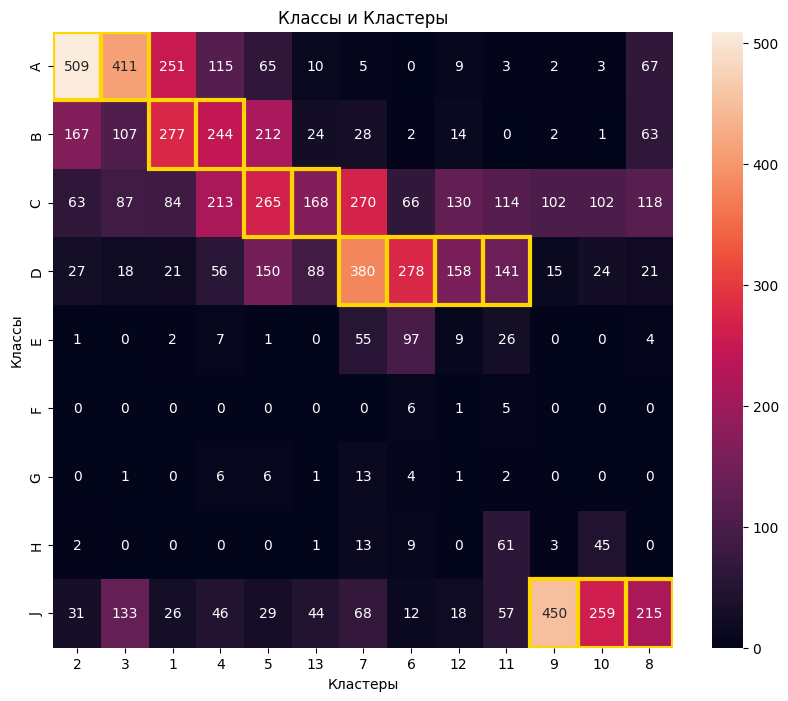

In [14]:
print(type_acc[['Type','Accuracy']],'\n')
print('Сумма максимальных значений', max_col['max_values'].sum())
print('Accuracy total', max_col['max_values'].sum() / crosstab.values.sum())

crosstab = crosstab[max_col['cluster']]

plt.figure(figsize=(10, 8))
ax = sns.heatmap(crosstab, annot=True, fmt='d', cbar=True)

#  отмечаем максимальные значения
for idx, row in max_col.iterrows():
    type_idx = list(crosstab.index).index(row['max_indices'])
    cluster_idx = list(crosstab.columns).index(row['cluster']) 
    ax.add_patch(plt.Rectangle((cluster_idx, type_idx), 1, 1, fill=False, edgecolor='gold', lw=3))
    
# Переименовываем столбцы, начиная с 1
# new_cluster_names = {old_name: f'{i+1}' for i, old_name in enumerate(max_col['cluster'])}
# crosstab.rename(columns=new_cluster_names, inplace=True)

plt.title('Классы и Кластеры')
plt.xlabel('Кластеры')
plt.ylabel('Классы')

plt.savefig('/kaggle/working/crosstab.jpg')
plt.show()

# **Оценка принадлежности кластеров классам при условии, что кластер может принадлежать разным классам**

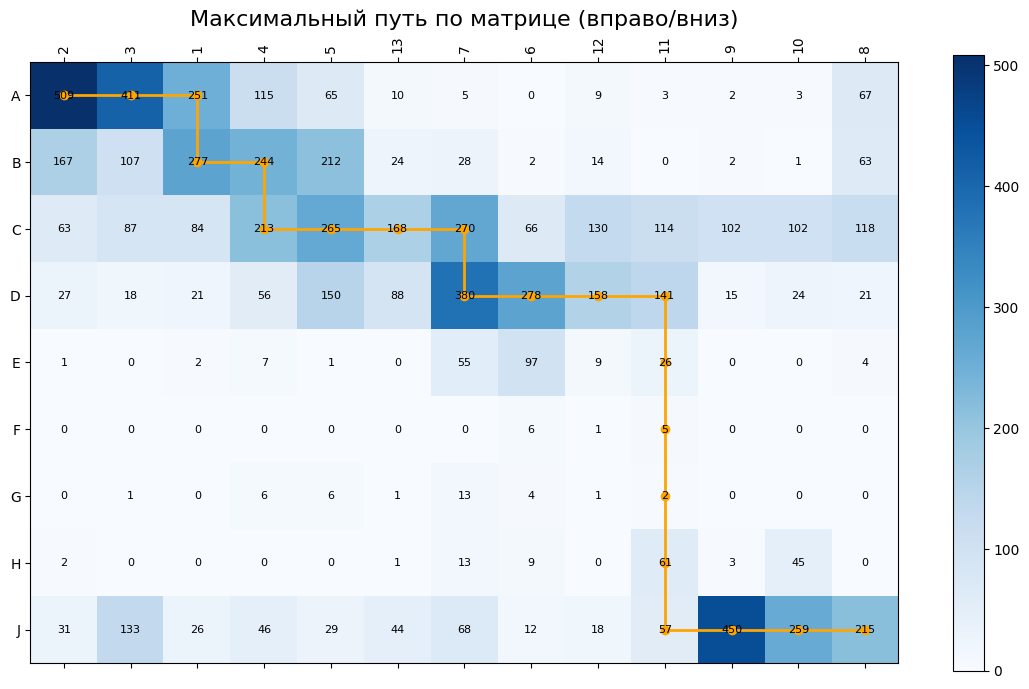

Максимальная суммы пути 4640
Accuracy 0.6170212765957447


In [86]:
# Преобразуем в numpy матрицу
matrix = crosstab.values
rows, cols = matrix.shape

# Инициализация массива DP
dp = np.zeros((rows, cols), dtype=int)
dp[0, 0] = matrix[0, 0]

# Заполняем первую строку (можно двигаться только вправо)
for j in range(1, cols):
    dp[0, j] = dp[0, j-1] + matrix[0, j]

# Заполняем первый столбец (можно двигаться только вниз)
for i in range(1, rows):
    dp[i, 0] = dp[i-1, 0] + matrix[i, 0]

# Заполняем всю остальную таблицу
for i in range(1, rows):
    for j in range(1, cols):
        dp[i, j] = max(dp[i-1, j], dp[i, j-1]) + matrix[i, j]

# Восстановление пути из DP
i, j = rows - 1, cols - 1
path = [(i, j)]
while (i > 0) or (j > 0):
    if i == 0:
        j -= 1
    elif j == 0:
        i -= 1
    else:
        if dp[i-1, j] >= dp[i, j-1]:
            i -= 1
        else:
            j -= 1
    path.append((i, j))
path = path[::-1]

# Построение графика
fig, ax = plt.subplots(figsize=(14, 8))
cax = ax.matshow(matrix, cmap='Blues')

for (i, j), val in np.ndenumerate(matrix):
    ax.text(j, i, f'{val}', va='center', ha='center', fontsize=8)

path_x = [p[1] for p in path]
path_y = [p[0] for p in path]
ax.plot(path_x, path_y, color='orange', linewidth=2, marker='o')

ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.set_xticklabels(crosstab.columns, rotation=90)
ax.set_yticklabels(crosstab.index)

plt.title("Максимальный путь по матрице (вправо/вниз)", fontsize=16)
plt.colorbar(cax)
plt.show()

print("Максимальная суммы пути",dp[-1, -1])
print("Accuracy",dp[-1, -1] / crosstab.values.sum())

# **перебор параметров**


In [ ]:
pca = PCA(n_components=2, random_state=0)
inv_emb_pca = pca.fit_transform(inv_emb)

df_inv_emb_pca = pd.DataFrame(inv_emb_pca, columns=['Component 1', 'Component 2'])
df_inv_emb_pca.index = inv_emb.index

hier_clust = linkage(df_inv_emb_pca, method='ward')
distances = hier_clust[-15:, 2]
distances_sorted = sorted(distances, reverse=True)

NUM = 10 # порог для разбиения на кластеры (число кластеров)
labels_inv_vae = fcluster(hier_clust, t=distances_sorted[NUM-1], criterion='distance')

df_inv_emb_pca['cluster'] = labels_inv_vae
df_inv_emb_pca = df_inv_emb_pca.reset_index()

link = pd.merge(zurich_class,df_inv_emb_pca, how='left', on='fname')
link = link[['fname','Date','Time','Latitude','Longitude','Type','cluster']]

crosstab = pd.crosstab(link['Type'], link['cluster'])

cost_matrix = -crosstab.values  # минус для максимизации
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# Список для нового порядка кластеров
cluster_order = []

for r, c in zip(row_ind, col_ind):
    cluster_order.append(crosstab.columns[c])
    #print(f'Класс: {crosstab.index[r]}, Кластер: {crosstab.columns[c]}, Значение: {crosstab.values[r][c]}')

# Переупорядочиваем столбцы 
crosstab = crosstab[cluster_order]

# Переименовываем столбцы 
new_cluster_names = {old_name: f'{i+1}' for i, old_name in enumerate(cluster_order)}
crosstab.rename(columns=new_cluster_names, inplace=True)

# Подсчет метрик
total = crosstab.values.sum()
TP = crosstab.values.diagonal().sum()

# Accuracy
accuracy = TP / total

# Precision, Recall, F1_score для каждого класса
precision = {}
recall = {}
f1_score = {}

for i in range(len(crosstab)):
    TP_i = crosstab.values[i][i] 
    FP_i = crosstab.iloc[:, i].sum() - TP_i  
    FN_i = crosstab.iloc[i].sum() - TP_i  
    
    precision[i] = TP_i / (TP_i + FP_i) if (TP_i + FP_i) > 0 else 0
    recall[i] = TP_i / (TP_i + FN_i) if (TP_i + FN_i) > 0 else 0
    
    # F1 Score
    f1_score[i] = (2 * precision[i] * recall[i]) / (precision[i] + recall[i]) if (precision[i] + recall[i]) > 0 else 0

# **Иерархическая кластеризация Invariant embeddings**

In [68]:
# Параметры для перебора
pca_n_components_list = [False, 2, 3, 4, 5, 10, 20]
num_clusters_list = sorted(set([int(x) for x in np.logspace(np.log10(2), np.log10(100), num=50)]))
linkage_methods = ['ward', 'average', 'complete','single','weighted','centroid','median']
standardize_options = [True, False]

# pca_n_components_list = [False, 2]
# num_clusters_list = [3,15]
# linkage_methods = ['ward']
# standardize_options = [False]

results = []

for standardize in standardize_options:
    for linkage_method in linkage_methods:
        for n_components in tqdm(pca_n_components_list, desc='PCA Components', leave=False):
            data = inv_emb.copy()
            
            # Стандартизация 
            if standardize:
                data = StandardScaler().fit_transform(data)
            else:
                data = data.values
            
            # PCA
            if n_components is not False:
                pca = PCA(n_components=n_components, random_state=0)
                inv_emb_pca = pca.fit_transform(data)
                df_inv_emb_pca = pd.DataFrame(inv_emb_pca, index=inv_emb.index)
            else:
                df_inv_emb_pca = pd.DataFrame(data, index=inv_emb.index)  # Используем оригинальные данные
            df_inv_emb_pca = df_inv_emb_pca.reset_index()
            
            # Кластеризация
            hier_clust = linkage(df_inv_emb_pca.drop(columns='fname'), method=linkage_method)
            distances = hier_clust[-1000:, 2]
            distances_sorted = sorted(distances, reverse=True)

            for NUM in num_clusters_list:
                # if NUM > len(distances_sorted):
                #     continue

                labels_inv_vae = fcluster(hier_clust, t=distances_sorted[NUM-1], criterion='distance')

                df_inv_emb_pca['cluster'] = labels_inv_vae

                # Соединение с изначальными метками
                link = pd.merge(zurich_class, df_inv_emb_pca, how='left', on='fname')
                link = link[['fname', 'Date', 'Time', 'Latitude', 'Longitude', 'Type', 'cluster']]

                # Crosstab
                crosstab = pd.crosstab(link['Type'], link['cluster'])

                if crosstab.shape[0] == 0 or crosstab.shape[1] == 0:
                    continue  # пропуск пустых таблиц

                # Изменяем порядок кластеров
                max_values = crosstab.max()
                max_indices = crosstab.idxmax()
                max_col = pd.DataFrame({
                    'max_values': max_values,
                    'max_indices': max_indices
                })
                max_col = max_col.sort_values(by=['max_indices', 'max_values'], ascending=[True, False]).reset_index()
                crosstab = crosstab[max_col['cluster']]

                # accuracy Type
                type_tp = max_col.groupby('max_indices')['max_values'].sum().reset_index(name='sum_max_values')
                type_total = crosstab.sum(axis=1).reset_index(name='sum_values')
                type_acc = pd.merge(type_total, type_tp, how='left', left_on='Type',right_on='max_indices') 
                type_acc.loc[type_acc['max_indices'].isna(), 'sum_max_values'] = 0
                type_acc['Accuracy'] = (type_acc['sum_max_values'] / type_acc['sum_values'])

                
                # Переименовываем столбцы, начиная с 1
                # new_cluster_names = {old_name: f'{i+1}' for i, old_name in enumerate(max_col['cluster'])}
                # crosstab.rename(columns=new_cluster_names, inplace=True)

                # Метрики
                total = crosstab.values.sum()
                sum_cluster_values =  max_col['max_values'].sum()
                accuracy = sum_cluster_values / total

                results.append({
                    'clustering_method': 'hier_clust',
                    'pca_n_components': n_components,
                    'num_clusters': NUM,
                    'linkage': linkage_method,
                    'standardize': standardize,
                    'sum_cluster_values': sum_cluster_values,
                    'all_cluster_values': total,
                    'accuracy_total': accuracy,
                    'accuracy_Type_A': type_acc[type_acc['Type']=='A']['Accuracy'][0],
                    'accuracy_Type_B': type_acc[type_acc['Type']=='B']['Accuracy'][1],
                    'accuracy_Type_C': type_acc[type_acc['Type']=='C']['Accuracy'][2],
                    'accuracy_Type_D': type_acc[type_acc['Type']=='D']['Accuracy'][3],
                    'accuracy_Type_E': type_acc[type_acc['Type']=='E']['Accuracy'][4],
                    'accuracy_Type_F': type_acc[type_acc['Type']=='F']['Accuracy'][5],
                    'accuracy_Type_G': type_acc[type_acc['Type']=='G']['Accuracy'][6],
                    'accuracy_Type_H': type_acc[type_acc['Type']=='H']['Accuracy'][7],
                    'accuracy_Type_J': type_acc[type_acc['Type']=='J']['Accuracy'][8]
                })

hier_df = pd.DataFrame(results)
hier_df = hier_df.sort_values(by='accuracy_total', ascending=False)

hier_df.to_csv('/kaggle/working/hier_inv_emb.csv',index=False)
hier_df 

,clustering_method,pca_n_components,num_clusters,linkage,standardize,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
1960,hier_clust,4,100,ward,False,4185,7520,0.556516,0.725517,0.419807,0.468575,0.587509,0.163366,0.0,0.0,0.261194,0.678674
1849,hier_clust,False,100,ward,False,4184,7520,0.556383,0.675862,0.522349,0.443883,0.597676,0.336634,0.0,0.0,0.156716,0.652017
1959,hier_clust,4,92,ward,False,4181,7520,0.555984,0.725517,0.413672,0.479237,0.587509,0.163366,0.0,0.0,0.261194,0.667147
1958,hier_clust,4,85,ward,False,4177,7520,0.555452,0.725517,0.413672,0.479237,0.601307,0.064356,0.0,0.0,0.350746,0.656340
1848,hier_clust,False,92,ward,False,4163,7520,0.553590,0.675862,0.509202,0.433782,0.606391,0.336634,0.0,0.0,0.156716,0.652017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3071,hier_clust,20,2,weighted,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
260,hier_clust,False,3,average,True,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
259,hier_clust,False,2,average,True,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
2257,hier_clust,10,2,average,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000


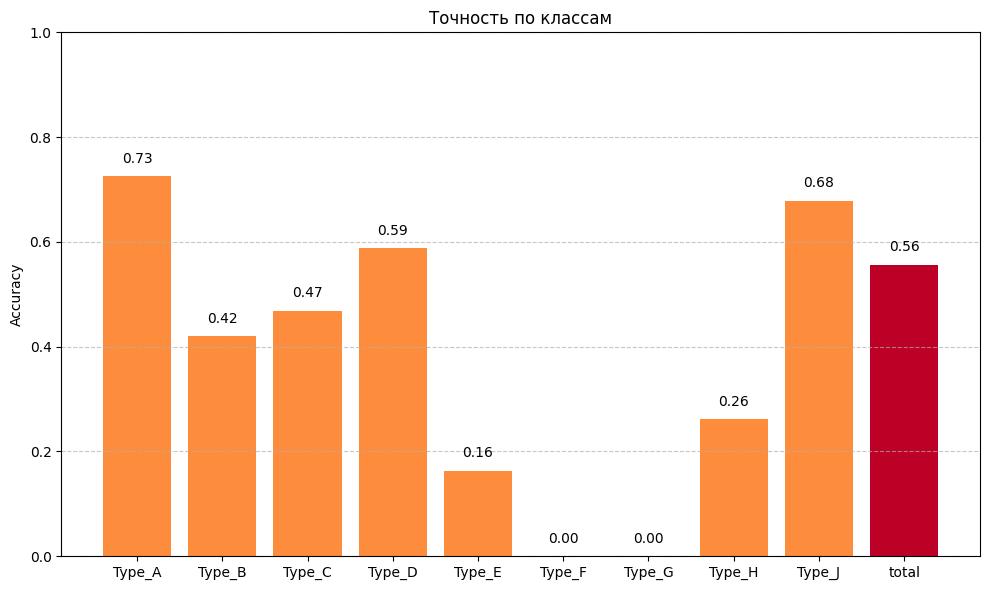

In [54]:
hier_inv_vae = pd.read_csv('/kaggle/input/hier-inv-emb/hier_inv_emb.csv')

cols_to_plot = [
    'accuracy_Type_A', 'accuracy_Type_B', 'accuracy_Type_C', 'accuracy_Type_D',
    'accuracy_Type_E', 'accuracy_Type_F', 'accuracy_Type_G', 'accuracy_Type_H',
    'accuracy_Type_J', 'accuracy_total'
]

row = hier_inv_vae.iloc[0]
values = [row[col] for col in cols_to_plot]
labels = [col.replace('accuracy_', '') for col in cols_to_plot]

# Построение столбчатой диаграммы
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#FD8D3C' if label != 'total' else '#BD0026' for label in labels])
plt.title("Точность по классам")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [57]:
hier_inv_vae

,clustering_method,pca_n_components,num_clusters,linkage,standardize,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
0,hier_clust,4,100,ward,False,4185,7520,0.556516,0.725517,0.419807,0.468575,0.587509,0.163366,0.0,0.0,0.261194,0.678674
1,hier_clust,False,100,ward,False,4184,7520,0.556383,0.675862,0.522349,0.443883,0.597676,0.336634,0.0,0.0,0.156716,0.652017
2,hier_clust,4,92,ward,False,4181,7520,0.555984,0.725517,0.413672,0.479237,0.587509,0.163366,0.0,0.0,0.261194,0.667147
3,hier_clust,4,85,ward,False,4177,7520,0.555452,0.725517,0.413672,0.479237,0.601307,0.064356,0.0,0.0,0.350746,0.656340
4,hier_clust,False,92,ward,False,4163,7520,0.553590,0.675862,0.509202,0.433782,0.606391,0.336634,0.0,0.0,0.156716,0.652017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3621,hier_clust,20,2,weighted,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
3622,hier_clust,False,3,average,True,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
3623,hier_clust,False,2,average,True,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
3624,hier_clust,10,2,average,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000


In [58]:
hier_inv_vae[['num_clusters','linkage','pca_n_components','accuracy_total']]

,num_clusters,accuracy_total,pca_n_components
0,100,0.556516,4
1,100,0.556383,False
2,92,0.555984,4
3,85,0.555452,4
4,92,0.553590,False
...,...,...,...
3621,2,0.236968,20
3622,3,0.236968,False
3623,2,0.236968,False
3624,2,0.236968,10


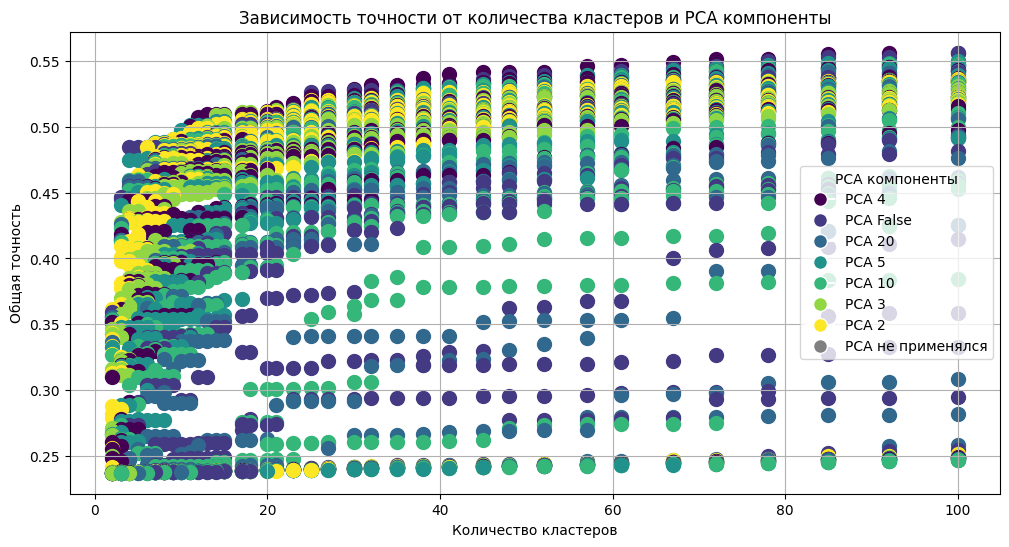

In [60]:
pca_data = df[df['pca_n_components'] != False]

# Определяем цвета на основе уникальных значений pca_n_components
unique_pca_components = pca_data['pca_n_components'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_pca_components)))

# Создаем словарь для соответствия цветов и pca_n_components
color_map = {comp: colors[i] for i, comp in enumerate(unique_pca_components)}

# Строим точечный график
plt.figure(figsize=(12, 6))

# Добавляем точки на график с цветами в зависимости от pca_n_components
for index, row in pca_data.iterrows():
    plt.scatter(row['num_clusters'], row['accuracy_total'], color=color_map[row['pca_n_components']], s=100)

# Добавляем точки с False в pca_n_components
non_pca_data = df[df['pca_n_components'] == False]
plt.scatter(non_pca_data['num_clusters'], non_pca_data['accuracy_total'], color='gray', s=100, label='PCA не применялся')

# Добавляем заголовок и метки осей
plt.title('Зависимость точности от количества кластеров и PCA компоненты')
plt.xlabel('Количество кластеров')
plt.ylabel('Общая точность')

# Отображаем сетку
plt.grid()

# Создаем легенду
handles = []
labels = []

# Добавляем метки для PCA компонентов
for comp in unique_pca_components:
    handle = plt.Line2D([0], [0], marker='o', color='w', label=f'PCA {comp}', markersize=10, markerfacecolor=color_map[comp])
    handles.append(handle)
    labels.append(f'PCA {comp}')

# Добавляем метку для случаев без PCA
handles.append(plt.Line2D([0], [0], marker='o', color='w', label='PCA не применялся', markersize=10, markerfacecolor='gray'))
labels.append('PCA не применялся')

plt.legend(handles=handles, labels=labels, title='PCA компоненты')

# Показываем график
plt.show()


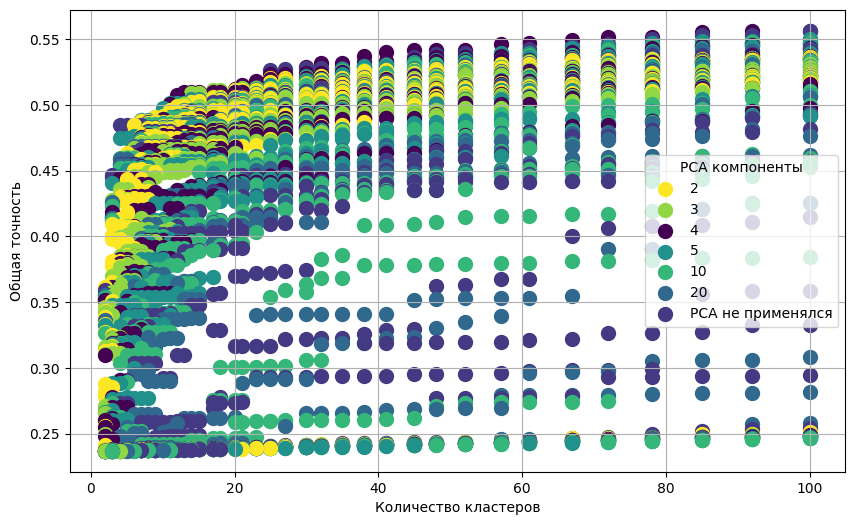

In [56]:
df = hier_inv_vae[['num_clusters','accuracy_total','pca_n_components']].drop_duplicates()
# Фильтрация данных для PCA (игнорируем False)
pca_data = df[df['pca_n_components'] != False]

# Определяем цвета на основе уникальных значений pca_n_components
unique_pca_components = pca_data['pca_n_components'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_pca_components)))

# Создаем словарь для соответствия цветов и pca_n_components
color_map = {comp: colors[i] for i, comp in enumerate(unique_pca_components)}

# Строим точечный график
plt.figure(figsize=(10, 6))

# Добавляем точки на график с цветами в зависимости от pca_n_components
for index, row in pca_data.iterrows():
    plt.scatter(row['num_clusters'], row['accuracy_total'], color=color_map[row['pca_n_components']], s=100, label=row['pca_n_components'])

# Добавляем заголовок и метки осей
#plt.title('Зависимость точности от количества кластеров и PCA компоненты')
plt.xlabel('Количество кластеров')
plt.ylabel('Общая точность')

# Отображаем сетку
plt.grid()

# Убираем дубликаты из легенды
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

custom_order = ['2', '3', '4', '5', '10', '20', 'PCA не применялся']
new_by_label = {key if key != 'False' else 'PCA не применялся': by_label[key] for key in by_label}

# Теперь создаем отсортированные списки значений и ключей
sorted_values = [new_by_label[key] for key in custom_order if key in new_by_label]
sorted_keys = [key for key in custom_order if key in new_by_label]

plt.legend(sorted_values, sorted_keys, title='PCA компоненты')

plt.savefig('/kaggle/working/total_acc_hier_inv_vae.jpg')
plt.show()

**визуализируем лучший вариант**

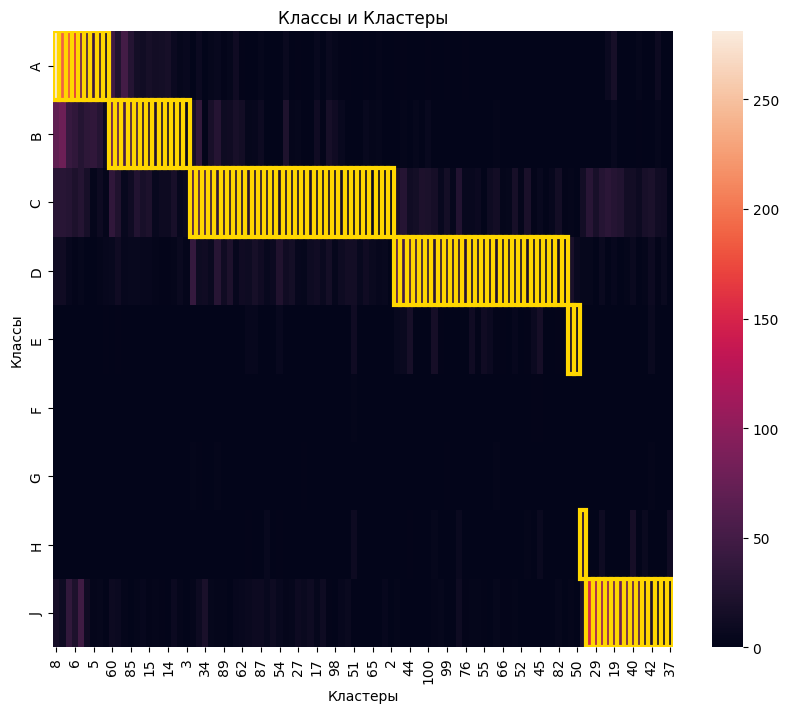

In [26]:
pca_n_components_list = [hier_df.iloc[0]['pca_n_components'].astype(int)]
num_clusters_list = [hier_df.iloc[0]['num_clusters']]
linkage_methods = [hier_df.iloc[0]['linkage']]
standardize_options = [hier_df.iloc[0]['standardize']]

for standardize in standardize_options:
    for linkage_method in linkage_methods:
        for n_components in pca_n_components_list:
            data = inv_emb.copy()
            
            # Стандартизация 
            if standardize:
                data = StandardScaler().fit_transform(data)
            else:
                data = data.values
            
            # PCA
            if n_components is not None:
                pca = PCA(n_components=n_components, random_state=0)
                inv_emb_pca = pca.fit_transform(data)
                df_inv_emb_pca = pd.DataFrame(inv_emb_pca, index=inv_emb.index)
            else:
                df_inv_emb_pca = pd.DataFrame(data, index=inv_emb.index)  # Используем оригинальные данные

            df_inv_emb_pca = df_inv_emb_pca.reset_index()
            
            # Кластеризация
            hier_clust = linkage(df_inv_emb_pca.drop(columns='fname'), method=linkage_method)
            distances = hier_clust[-1000:, 2]
            distances_sorted = sorted(distances, reverse=True)

            for NUM in num_clusters_list:
                # if NUM > len(distances_sorted):
                #     continue

                labels_inv_vae = fcluster(hier_clust, t=distances_sorted[NUM-1], criterion='distance')

                df_inv_emb_pca['cluster'] = labels_inv_vae

                # Соединение с изначальными метками
                link = pd.merge(zurich_class, df_inv_emb_pca, how='left', on='fname')
                link = link[['fname', 'Date', 'Time', 'Latitude', 'Longitude', 'Type', 'cluster']]

                # Crosstab
                crosstab = pd.crosstab(link['Type'], link['cluster'])

                if crosstab.shape[0] == 0 or crosstab.shape[1] == 0:
                    continue  # пропуск пустых таблиц

                # Изменяем порядок кластеров
                max_values = crosstab.max()
                max_indices = crosstab.idxmax()
                max_col = pd.DataFrame({
                    'max_values': max_values,
                    'max_indices': max_indices
                })
                max_col = max_col.sort_values(by=['max_indices', 'max_values'], ascending=[True, False]).reset_index()
                crosstab = crosstab[max_col['cluster']]

plt.figure(figsize=(10, 8))
ax = sns.heatmap(crosstab, annot=False, fmt='d', cbar=True)

#  отмечаем максимальные значения
for idx, row in max_col.iterrows():
    type_idx = list(crosstab.index).index(row['max_indices'])
    cluster_idx = list(crosstab.columns).index(row['cluster']) 
    ax.add_patch(plt.Rectangle((cluster_idx, type_idx), 1, 1, fill=False, edgecolor='gold', lw=3))


plt.title('Классы и Кластеры')
plt.xlabel('Кластеры')
plt.ylabel('Классы')
plt.show()

In [17]:
hier_inv_vae[hier_inv_vae['num_clusters']==15]

,clustering_method,pca_n_components,num_clusters,linkage,standardize,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
646,hier_clust,4,15,ward,False,3832,7520,0.509574,0.677241,0.495180,0.226712,0.633261,0.000000,0.0,0.0,0.000000,0.726945
665,hier_clust,3,15,ward,False,3829,7520,0.509176,0.766207,0.428571,0.365320,0.500363,0.000000,0.0,0.0,0.000000,0.640490
781,hier_clust,2,15,average,False,3796,7520,0.504787,0.813793,0.339176,0.276655,0.616558,0.000000,0.0,0.0,0.000000,0.639049
793,hier_clust,2,15,complete,True,3795,7520,0.504654,0.775862,0.397897,0.370932,0.470588,0.000000,0.0,0.0,0.000000,0.653458
795,hier_clust,5,15,ward,False,3795,7520,0.504654,0.735172,0.344435,0.230640,0.716049,0.000000,0.0,0.0,0.000000,0.676513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,hier_clust,False,15,single,False,1791,7520,0.238165,0.000000,0.001753,1.000000,0.002905,0.004950,0.0,0.0,0.000000,0.001441
3260,hier_clust,False,15,median,False,1791,7520,0.238165,0.000000,0.001753,0.999439,0.002179,0.009901,0.0,0.0,0.000000,0.002161
3267,hier_clust,20,15,centroid,True,1791,7520,0.238165,0.000000,0.000000,1.000000,0.003631,0.004950,0.0,0.0,0.000000,0.002161
3289,hier_clust,10,15,median,False,1790,7520,0.238032,0.001379,0.000000,1.000000,0.002179,0.000000,0.0,0.0,0.000000,0.002161


In [48]:
# Параметры для перебора
pca_n_components_list = [4]
num_clusters_list = [15]
linkage_methods = ['ward']
standardize_options = [False]

# pca_n_components_list = [False, 2]
# num_clusters_list = [3,15]
# linkage_methods = ['ward']
# standardize_options = [False]

results = []

for standardize in standardize_options:
    for linkage_method in linkage_methods:
        for n_components in tqdm(pca_n_components_list, desc='PCA Components', leave=False):
            data = inv_emb.copy()
            
            # Стандартизация 
            if standardize:
                data = StandardScaler().fit_transform(data)
            else:
                data = data.values
            
            # PCA
            if n_components is not False:
                pca = PCA(n_components=n_components, random_state=0)
                inv_emb_pca = pca.fit_transform(data)
                df_inv_emb_pca = pd.DataFrame(inv_emb_pca, index=inv_emb.index)
            else:
                df_inv_emb_pca = pd.DataFrame(data, index=inv_emb.index)  # Используем оригинальные данные
            df_inv_emb_pca = df_inv_emb_pca.reset_index()
            
            # Кластеризация
            hier_clust = linkage(df_inv_emb_pca.drop(columns='fname'), method=linkage_method)
            distances = hier_clust[-1000:, 2]
            distances_sorted = sorted(distances, reverse=True)

            for NUM in num_clusters_list:
                # if NUM > len(distances_sorted):
                #     continue

                labels_inv_vae = fcluster(hier_clust, t=distances_sorted[NUM-1], criterion='distance')

                df_inv_emb_pca['cluster'] = labels_inv_vae

                # Соединение с изначальными метками
                link = pd.merge(zurich_class, df_inv_emb_pca, how='left', on='fname')
                link = link[['fname', 'Date', 'Time', 'Latitude', 'Longitude', 'Type', 'cluster']]

                # Crosstab
                crosstab = pd.crosstab(link['Type'], link['cluster'])

                if crosstab.shape[0] == 0 or crosstab.shape[1] == 0:
                    continue  # пропуск пустых таблиц

                # Изменяем порядок кластеров
                max_values = crosstab.max()
                max_indices = crosstab.idxmax()
                max_col = pd.DataFrame({
                    'max_values': max_values,
                    'max_indices': max_indices
                })
                max_col = max_col.sort_values(by=['max_indices', 'max_values'], ascending=[True, False]).reset_index()
                crosstab = crosstab[max_col['cluster']]

                # accuracy Type
                type_tp = max_col.groupby('max_indices')['max_values'].sum().reset_index(name='sum_max_values')
                type_total = crosstab.sum(axis=1).reset_index(name='sum_values')
                type_acc = pd.merge(type_total, type_tp, how='left', left_on='Type',right_on='max_indices') 
                type_acc.loc[type_acc['max_indices'].isna(), 'sum_max_values'] = 0
                type_acc['Accuracy'] = (type_acc['sum_max_values'] / type_acc['sum_values'])

                
                # Переименовываем столбцы, начиная с 1
                # new_cluster_names = {old_name: f'{i+1}' for i, old_name in enumerate(max_col['cluster'])}
                # crosstab.rename(columns=new_cluster_names, inplace=True)

                # Метрики
                total = crosstab.values.sum()
                sum_cluster_values =  max_col['max_values'].sum()
                accuracy = sum_cluster_values / total

                results.append({
                    'clustering_method': 'hier_clust',
                    'pca_n_components': n_components,
                    'num_clusters': NUM,
                    'linkage': linkage_method,
                    'standardize': standardize,
                    'sum_cluster_values': sum_cluster_values,
                    'all_cluster_values': total,
                    'accuracy_total': accuracy,
                    'accuracy_Type_A': type_acc[type_acc['Type']=='A']['Accuracy'][0],
                    'accuracy_Type_B': type_acc[type_acc['Type']=='B']['Accuracy'][1],
                    'accuracy_Type_C': type_acc[type_acc['Type']=='C']['Accuracy'][2],
                    'accuracy_Type_D': type_acc[type_acc['Type']=='D']['Accuracy'][3],
                    'accuracy_Type_E': type_acc[type_acc['Type']=='E']['Accuracy'][4],
                    'accuracy_Type_F': type_acc[type_acc['Type']=='F']['Accuracy'][5],
                    'accuracy_Type_G': type_acc[type_acc['Type']=='G']['Accuracy'][6],
                    'accuracy_Type_H': type_acc[type_acc['Type']=='H']['Accuracy'][7],
                    'accuracy_Type_J': type_acc[type_acc['Type']=='J']['Accuracy'][8]
                })


hier_df = pd.DataFrame(results)
hier_df = hier_df.sort_values(by='accuracy_total', ascending=False)

hier_df.to_csv('/kaggle/working/hier_inv_emb.csv',index=False)
hier_df 

,clustering_method,pca_n_components,num_clusters,linkage,standardize,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
0,hier_clust,4,15,ward,False,3832,7520,0.509574,0.677241,0.49518,0.226712,0.633261,0.0,0.0,0.0,0.0,0.726945


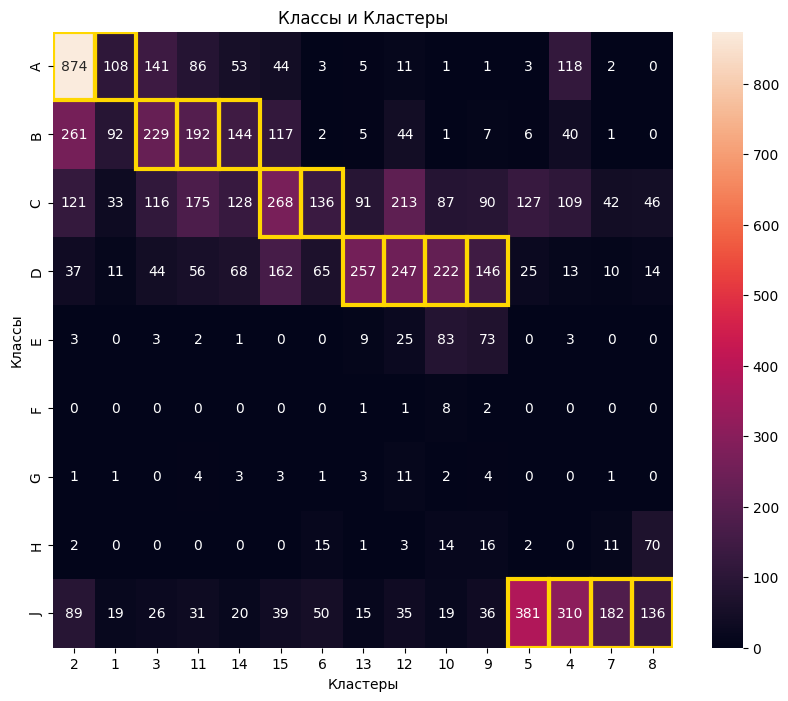

In [47]:
plt.figure(figsize=(10, 8))
ax = sns.heatmap(crosstab, annot=True, fmt='d', cbar=True)

#  отмечаем максимальные значения
for idx, row in max_col.iterrows():
    type_idx = list(crosstab.index).index(row['max_indices'])
    cluster_idx = list(crosstab.columns).index(row['cluster']) 
    ax.add_patch(plt.Rectangle((cluster_idx, type_idx), 1, 1, fill=False, edgecolor='gold', lw=3))
    
# Переименовываем столбцы, начиная с 1
# new_cluster_names = {old_name: f'{i+1}' for i, old_name in enumerate(max_col['cluster'])}
# crosstab.rename(columns=new_cluster_names, inplace=True)

plt.title('Классы и Кластеры')
plt.xlabel('Кластеры')
plt.ylabel('Классы')
plt.show()

In [19]:
df_inv_emb_pca

,fname,0,1,2,3,cluster
0,201007230452_63,6.722087,-3.372190,2.014786,0.267096,10
1,201007240414_63,4.168566,-6.150291,-3.945156,2.639997,13
2,201007250447_63,4.547601,-4.136571,1.298940,-0.835741,12
3,201007250447_64,-7.023856,-0.066776,0.303158,0.473907,2
4,201007260349_63,2.408206,-3.020230,2.007386,-2.774657,12
...,...,...,...,...,...,...
8493,202008120532_31,-6.190830,-1.660569,0.670161,1.536753,2
8494,202008120532_33,-5.304947,-2.274616,-0.111031,1.854927,2
8495,202008180351_34,-7.045453,-0.322968,0.091827,1.010313,2
8496,202008190344_34,2.368730,2.399539,2.553514,5.924858,1


In [27]:
df_inv_emb_pca = df_inv_emb_pca.set_index('fname')
clusters = {key: [] for key in set(df_inv_emb_pca['cluster'])}

for idx, row in df_inv_emb_pca.iterrows():
    clusters[row['cluster']].append(idx)

In [28]:
num_clusts = []
sampled_clusters = {}
for cluster_num, indices in clusters.items():
    sampled_clusters[cluster_num] = indices[0:5] #random.choices(indices, k=5)
    #print(f"Кластер {cluster_num}. Элементов: {len(indices)}: {sampled_clusters[cluster_num]}")
    num_clusts.append(len(indices))
    

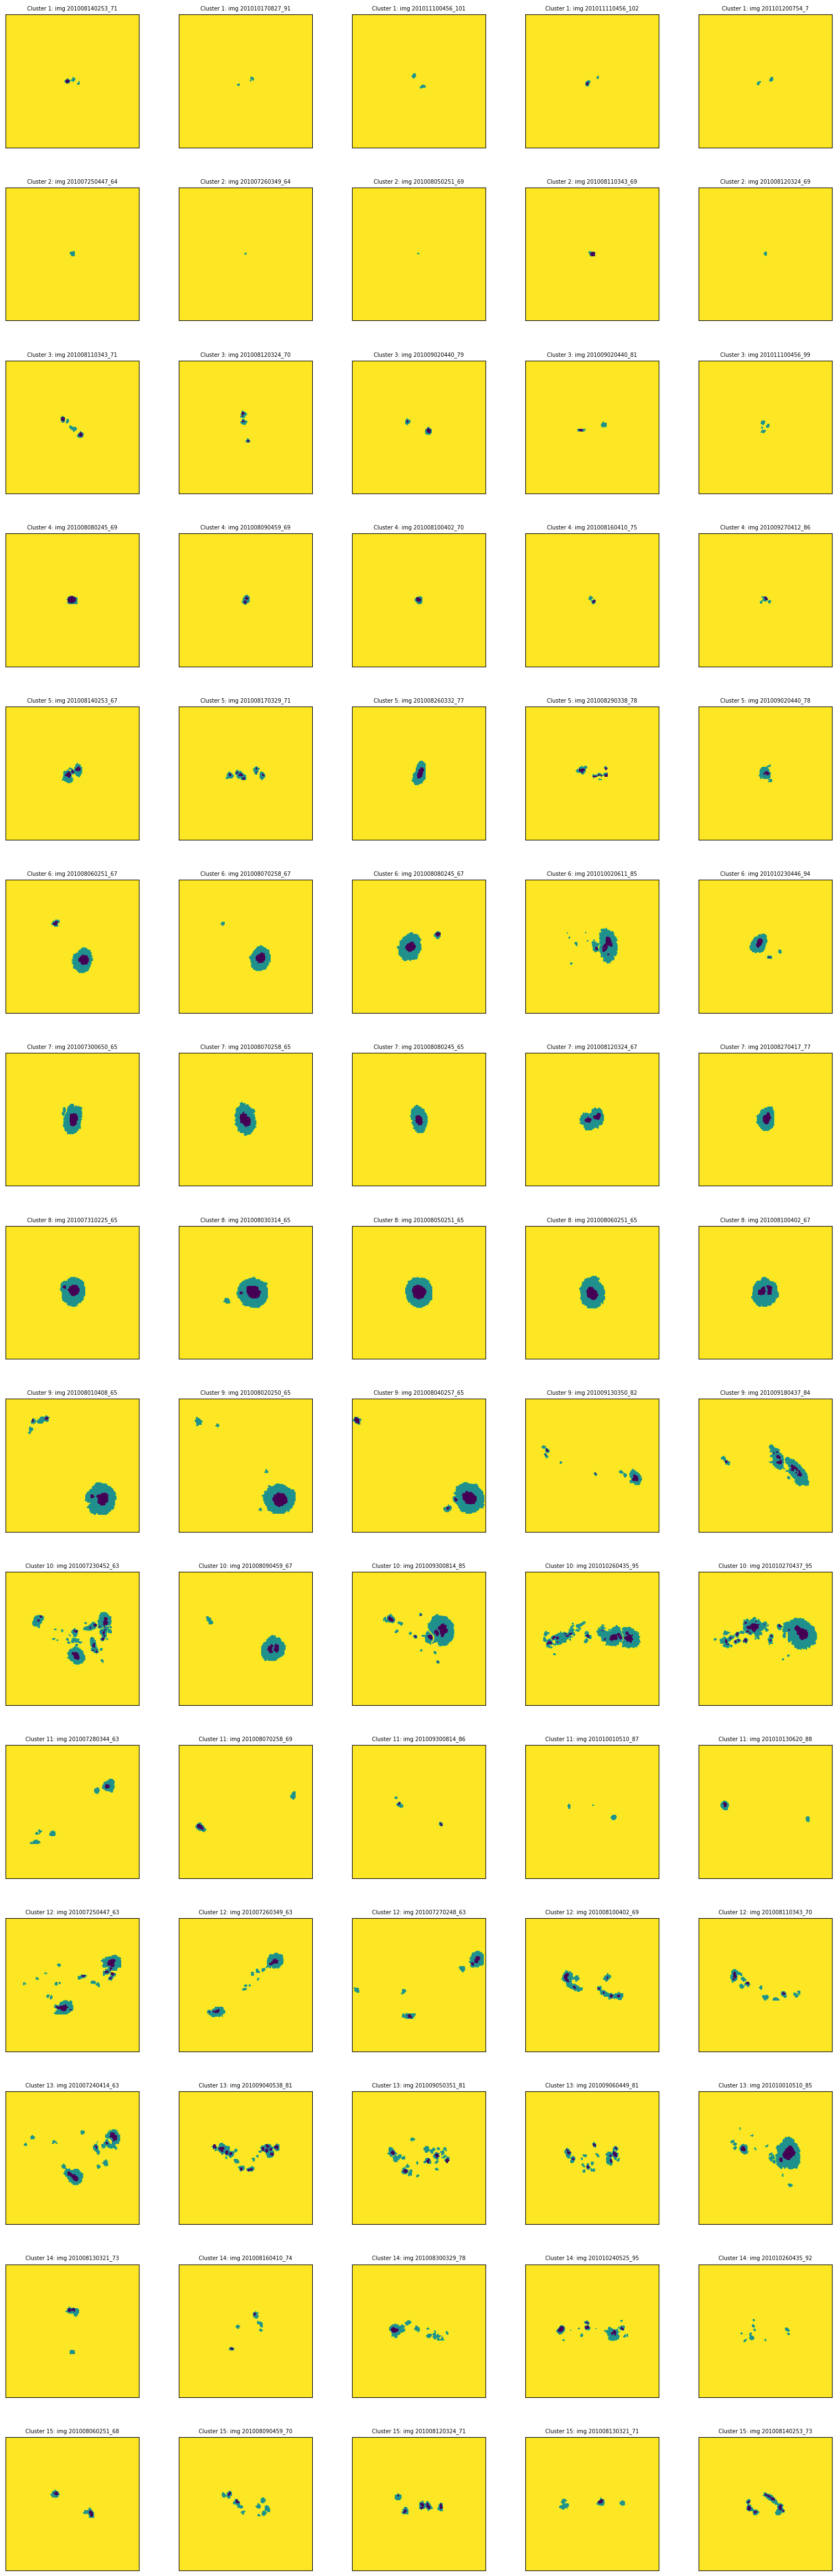

In [44]:
fig, ax = plt.subplots(15, len(sampled_clusters[1]), figsize=(20, 60))
fig.patch.set_facecolor('xkcd:white')
plt.subplots_adjust(wspace=0.05, hspace=0.3)
for i, (key, color_clust) in enumerate(sampled_clusters.items()):    
    #print(itrain.loc[color_clust])
    #print(HelioBatch(itrain.iloc[color_clust]))
    with torch.no_grad():
        batch = (HelioBatch(itrain.loc[color_clust])
                 .load('img', sparse=True)
                 .apply(lambda x: x.toarray().reshape(256, 256, 3), src='img')
                 .apply(transform_channels, src='img'))
        
        x = torch.tensor(np.stack(batch.img)).to(device)

    for j in range(len(sampled_clusters[1])):
        ax[i][j].imshow(1-x[j,0].detach().cpu().numpy(),vmin=0, vmax=1)
        ax[i][j].set_title('Cluster {}: img {}'.format(key, color_clust[j]), fontsize=7)
        ax[i][j].set_xticks([])
        ax[i][j].set_yticks([])
#plt.suptitle('Method ward',fontsize=16)
plt.savefig('/kaggle/working/invEmpHier_15_clust.png', dpi=300, bbox_inches='tight')
plt.show()

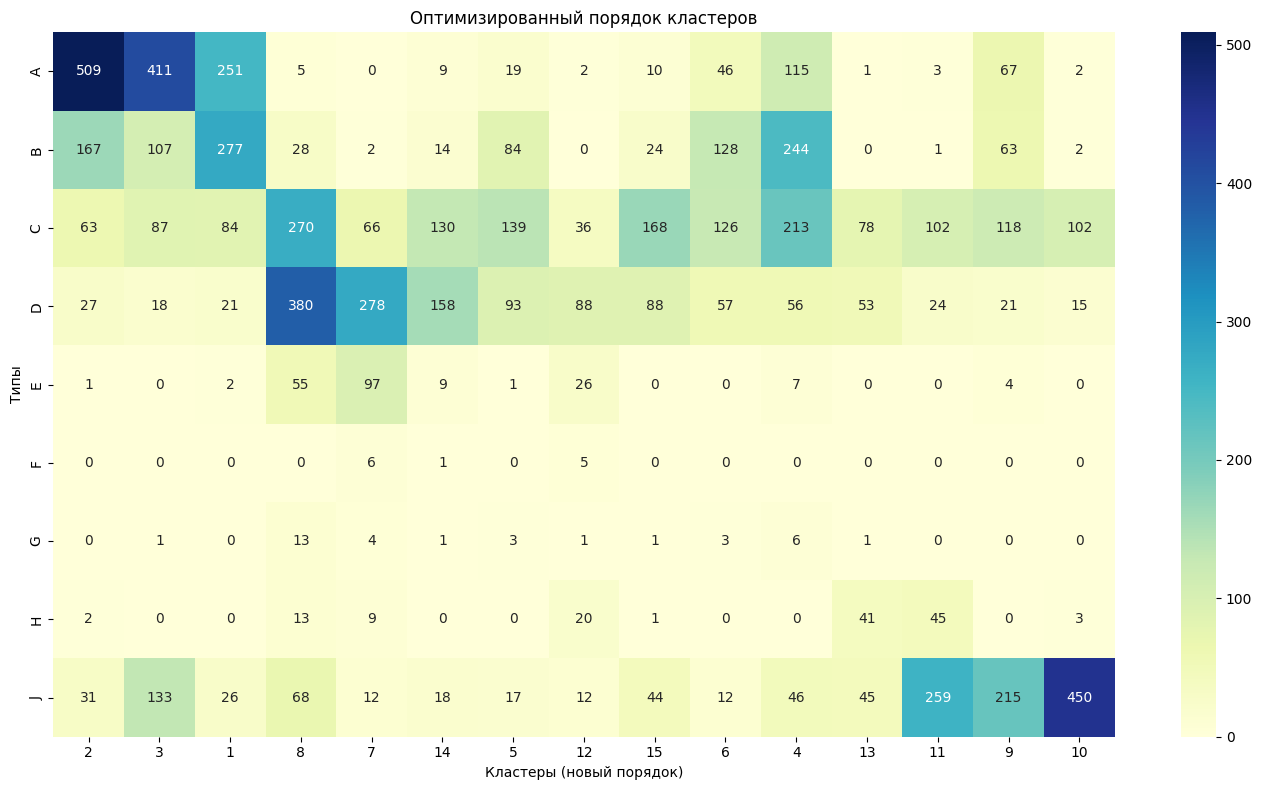

In [110]:
# 2. Настройки
available_clusters = set(crosstab.columns)
final_order = []
types = list(crosstab.index)

# 3. Старт: первые два максимума из A
# сначала 509 -> cluster 1
first = crosstab.loc['A', list(available_clusters)].idxmax()
final_order.append(first)
available_clusters.remove(first)

# потом 411 -> cluster 10
second = crosstab.loc['A', list(available_clusters)].idxmax()
final_order.append(second)
available_clusters.remove(second)

# 4. Дальше пошаговое движение по строкам
current_type_idx = 0  # начинаем с A

while available_clusters:
    current_type = types[current_type_idx]
    next_type_idx = (current_type_idx + 1) % len(types)
    next_type = types[next_type_idx]
    
    # Максимумы для текущего и следующего типа
    row_current = crosstab.loc[current_type, list(available_clusters)]
    row_next = crosstab.loc[next_type, list(available_clusters)]
    
    if not row_current.empty:
        best_current_cluster = row_current.idxmax()
        best_current_value = row_current.max()
    else:
        best_current_value = -1

    if not row_next.empty:
        best_next_cluster = row_next.idxmax()
        best_next_value = row_next.max()
    else:
        best_next_value = -1

    # Сравниваем значения
    if best_current_value >= best_next_value:
        chosen_cluster = best_current_cluster
    else:
        chosen_cluster = best_next_cluster
        current_type_idx = next_type_idx  # переключаемся на следующего
    
    final_order.append(chosen_cluster)
    available_clusters.remove(chosen_cluster)

# 5. Переупорядочиваем столбцы
reordered_crosstab = crosstab[final_order]

# 6. Визуализация
plt.figure(figsize=(14, 8))
sns.heatmap(reordered_crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Оптимизированный порядок кластеров')
plt.xlabel('Кластеры (новый порядок)')
plt.ylabel('Типы')
plt.tight_layout()
plt.show()

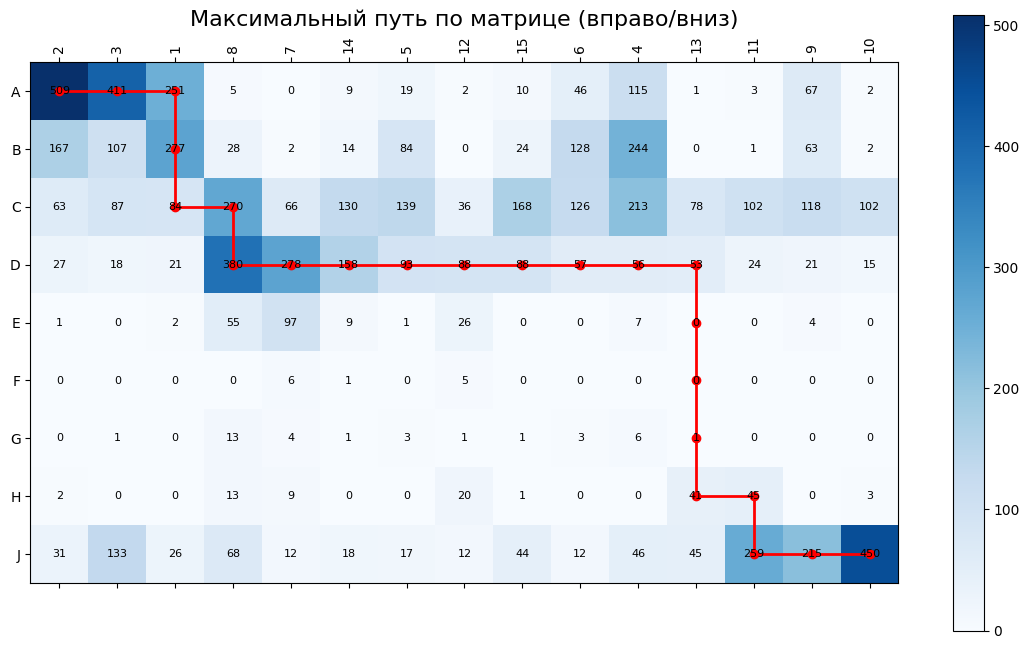

Максимальная суммы пути 4064
Accuracy 0.5404255319148936


In [112]:
# Преобразуем в numpy матрицу
matrix = reordered_crosstab.values
rows, cols = matrix.shape

# Инициализация массива DP
dp = np.zeros((rows, cols), dtype=int)
dp[0, 0] = matrix[0, 0]

# Заполняем первую строку (можно двигаться только вправо)
for j in range(1, cols):
    dp[0, j] = dp[0, j-1] + matrix[0, j]

# Заполняем первый столбец (можно двигаться только вниз)
for i in range(1, rows):
    dp[i, 0] = dp[i-1, 0] + matrix[i, 0]

# Заполняем всю остальную таблицу
for i in range(1, rows):
    for j in range(1, cols):
        dp[i, j] = max(dp[i-1, j], dp[i, j-1]) + matrix[i, j]

# Восстановление пути из DP
i, j = rows - 1, cols - 1
path = [(i, j)]
while (i > 0) or (j > 0):
    if i == 0:
        j -= 1
    elif j == 0:
        i -= 1
    else:
        if dp[i-1, j] >= dp[i, j-1]:
            i -= 1
        else:
            j -= 1
    path.append((i, j))
path = path[::-1]

# Построение графика
fig, ax = plt.subplots(figsize=(14, 8))
cax = ax.matshow(matrix, cmap='Blues')

for (i, j), val in np.ndenumerate(matrix):
    ax.text(j, i, f'{val}', va='center', ha='center', fontsize=8)

path_x = [p[1] for p in path]
path_y = [p[0] for p in path]
ax.plot(path_x, path_y, color='red', linewidth=2, marker='o')

ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.set_xticklabels(reordered_crosstab.columns, rotation=90)
ax.set_yticklabels(reordered_crosstab.index)

plt.title("Максимальный путь по матрице (вправо/вниз)", fontsize=16)
plt.colorbar(cax)
plt.show()

# Вывод максимальной суммы пути
print("Максимальная суммы пути",dp[-1, -1])
print("Accuracy",dp[-1, -1] / reordered_crosstab.values.sum())

# **KMeans Invariant embeddings**

In [303]:
df_inv_emb_pca = None

In [69]:
# Параметры для перебора
pca_n_components_list = [False, 2, 3, 4, 5, 10, 20]
num_clusters_list = sorted(set([int(x) for x in np.logspace(np.log10(2), np.log10(100), num=50)]))
standardize_options = [True, False]

# pca_n_components_list = [2]
# num_clusters_list = [15]
# linkage_methods = ['ward']
# standardize_options = [False]

results = []

for standardize in standardize_options:
    for n_components in tqdm(pca_n_components_list, desc='PCA Components', leave=False):
        data = inv_emb.copy()
        
        # Стандартизация 
        if standardize:
            data = StandardScaler().fit_transform(data)
        else:
            data = data.values
        
        # PCA
        if n_components is not False:
            pca = PCA(n_components=n_components, random_state=0)
            inv_emb_pca = pca.fit_transform(data)
            df_inv_emb_pca = pd.DataFrame(inv_emb_pca, index=inv_emb.index)
        else:
            df_inv_emb_pca = pd.DataFrame(data, index=inv_emb.index)  # Используем оригинальные данные
        df_inv_emb_pca = df_inv_emb_pca.reset_index()
        
        # Кластеризация
        kmeans = KMeans(n_clusters=NUM, random_state=0, n_init='auto')
        labels_inv_vae = kmeans.fit_predict(df_inv_emb_pca.drop(columns='fname'))
        df_inv_emb_pca.columns = df_inv_emb_pca.columns.astype(str)
        for NUM in num_clusters_list:
            labels_inv_vae = fcluster(hier_clust, t=distances_sorted[NUM-1], criterion='distance')
            df_inv_emb_pca['cluster'] = labels_inv_vae
            # Соединение с изначальными метками
            link = pd.merge(zurich_class, df_inv_emb_pca, how='left', on='fname')
            link = link[['fname', 'Date', 'Time', 'Latitude', 'Longitude', 'Type', 'cluster']]
            # Crosstab
            crosstab = pd.crosstab(link['Type'], link['cluster'])
            if crosstab.shape[0] == 0 or crosstab.shape[1] == 0:
                continue  # пропуск пустых таблиц
            # Изменяем порядок кластеров
            max_values = crosstab.max()
            max_indices = crosstab.idxmax()
            max_col = pd.DataFrame({
                'max_values': max_values,
                'max_indices': max_indices
            })
            max_col = max_col.sort_values(by=['max_indices', 'max_values'], ascending=[True, False]).reset_index()
            crosstab = crosstab[max_col['cluster']]

            # accuracy Type
            type_tp = max_col.groupby('max_indices')['max_values'].sum().reset_index(name='sum_max_values')
            type_total = crosstab.sum(axis=1).reset_index(name='sum_values')
            type_acc = pd.merge(type_total, type_tp, how='left', left_on='Type',right_on='max_indices') 
            type_acc.loc[type_acc['max_indices'].isna(), 'sum_max_values'] = 0
            type_acc['Accuracy'] = (type_acc['sum_max_values'] / type_acc['sum_values'])
            
            # Переименовываем столбцы, начиная с 1
            # new_cluster_names = {old_name: f'{i+1}' for i, old_name in enumerate(max_col['cluster'])}
            # crosstab.rename(columns=new_cluster_names, inplace=True)
            # Метрики
            total = crosstab.values.sum()
            sum_cluster_values =  max_col['max_values'].sum()
            accuracy = sum_cluster_values / total
            results.append({
                'clustering_method': 'kmeans',
                'pca_n_components': n_components,
                'num_clusters': NUM,
                'standardize': standardize,
                'sum_cluster_values': sum_cluster_values,
                'all_cluster_values': total,
                'accuracy_total': accuracy,
                'accuracy_Type_A': type_acc[type_acc['Type']=='A']['Accuracy'][0],
                'accuracy_Type_B': type_acc[type_acc['Type']=='B']['Accuracy'][1],
                'accuracy_Type_C': type_acc[type_acc['Type']=='C']['Accuracy'][2],
                'accuracy_Type_D': type_acc[type_acc['Type']=='D']['Accuracy'][3],
                'accuracy_Type_E': type_acc[type_acc['Type']=='E']['Accuracy'][4],
                'accuracy_Type_F': type_acc[type_acc['Type']=='F']['Accuracy'][5],
                'accuracy_Type_G': type_acc[type_acc['Type']=='G']['Accuracy'][6],
                'accuracy_Type_H': type_acc[type_acc['Type']=='H']['Accuracy'][7],
                'accuracy_Type_J': type_acc[type_acc['Type']=='J']['Accuracy'][8]
            })

kmeans_df = pd.DataFrame(results)
kmeans_df = kmeans_df.sort_values(by='accuracy_total', ascending=False)

kmeans_df.to_csv('/kaggle/working/kmeans_inv_emb.csv',index=False)
kmeans_df 

,clustering_method,pca_n_components,num_clusters,standardize,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
517,kmeans,20,100,False,3200,7520,0.425532,0.853793,0.007888,0.134119,0.744372,0.148515,0.166667,0.029412,0.0,0.472622
73,kmeans,2,100,True,3200,7520,0.425532,0.853793,0.007888,0.134119,0.744372,0.148515,0.166667,0.029412,0.0,0.472622
406,kmeans,4,100,False,3200,7520,0.425532,0.853793,0.007888,0.134119,0.744372,0.148515,0.166667,0.029412,0.0,0.472622
147,kmeans,4,100,True,3200,7520,0.425532,0.853793,0.007888,0.134119,0.744372,0.148515,0.166667,0.029412,0.0,0.472622
258,kmeans,20,100,True,3200,7520,0.425532,0.853793,0.007888,0.134119,0.744372,0.148515,0.166667,0.029412,0.0,0.472622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,kmeans,5,2,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
408,kmeans,5,3,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
444,kmeans,10,2,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
445,kmeans,10,3,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000


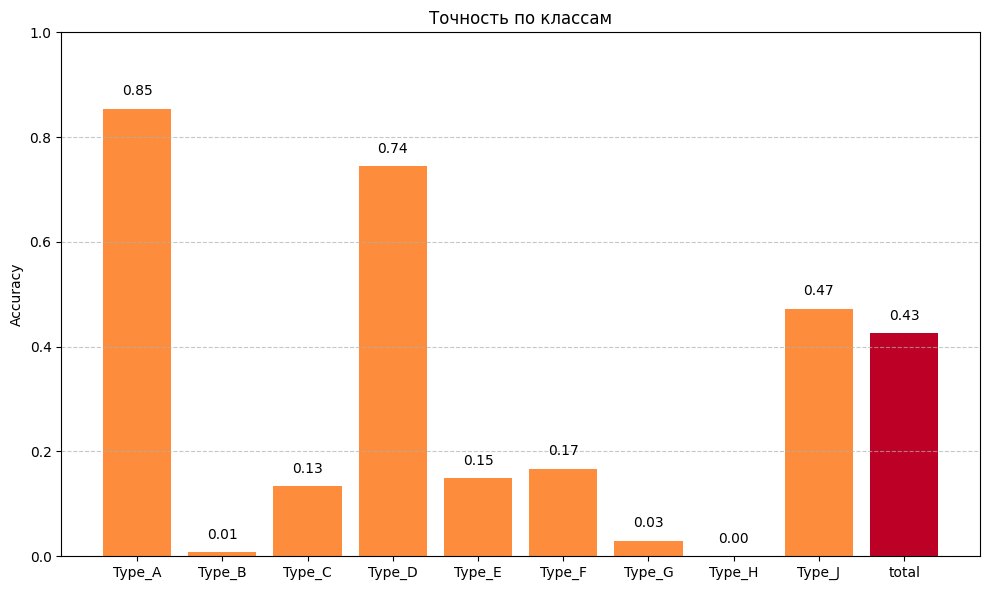

In [2]:
kmeans_inv_vae = pd.read_csv('/kaggle/input/kmeans-inv-emb/kmeans_inv_emb.csv')

cols_to_plot = [
    'accuracy_Type_A', 'accuracy_Type_B', 'accuracy_Type_C', 'accuracy_Type_D',
    'accuracy_Type_E', 'accuracy_Type_F', 'accuracy_Type_G', 'accuracy_Type_H',
    'accuracy_Type_J', 'accuracy_total'
]

row = kmeans_inv_vae.iloc[0]
values = [row[col] for col in cols_to_plot]
labels = [col.replace('accuracy_', '') for col in cols_to_plot]

# Построение столбчатой диаграммы
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#FD8D3C' if label != 'total' else '#BD0026' for label in labels])
plt.title("Точность по классам")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
kmeans_inv_vae

,clustering_method,pca_n_components,num_clusters,standardize,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
0,kmeans,20,100,False,3200,7520,0.425532,0.853793,0.007888,0.134119,0.744372,0.148515,0.166667,0.029412,0.0,0.472622
1,kmeans,2,100,True,3200,7520,0.425532,0.853793,0.007888,0.134119,0.744372,0.148515,0.166667,0.029412,0.0,0.472622
2,kmeans,4,100,False,3200,7520,0.425532,0.853793,0.007888,0.134119,0.744372,0.148515,0.166667,0.029412,0.0,0.472622
3,kmeans,4,100,True,3200,7520,0.425532,0.853793,0.007888,0.134119,0.744372,0.148515,0.166667,0.029412,0.0,0.472622
4,kmeans,20,100,True,3200,7520,0.425532,0.853793,0.007888,0.134119,0.744372,0.148515,0.166667,0.029412,0.0,0.472622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,kmeans,5,2,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
514,kmeans,5,3,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
515,kmeans,10,2,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
516,kmeans,10,3,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000


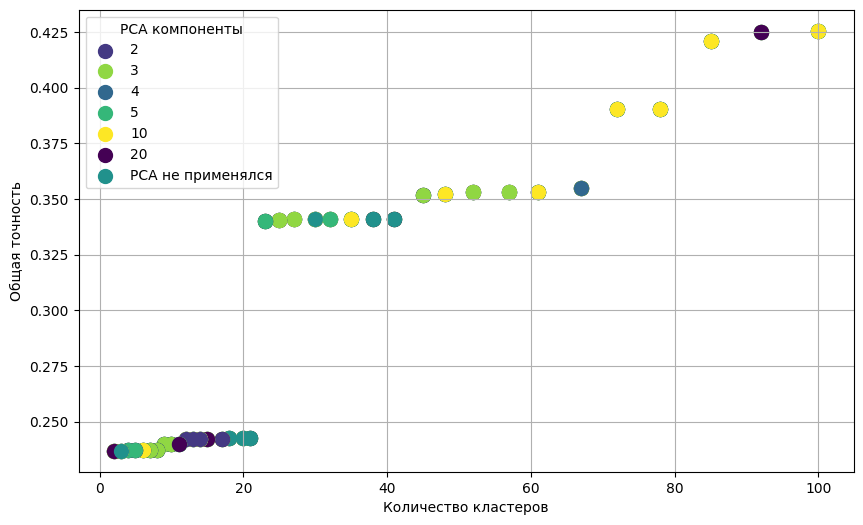

In [53]:
df = kmeans_inv_vae[['num_clusters','accuracy_total','pca_n_components']].drop_duplicates()
# Фильтрация данных для PCA (игнорируем False)
pca_data = df[df['pca_n_components'] != False]

# Определяем цвета на основе уникальных значений pca_n_components
unique_pca_components = pca_data['pca_n_components'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_pca_components)))

# Создаем словарь для соответствия цветов и pca_n_components
color_map = {comp: colors[i] for i, comp in enumerate(unique_pca_components)}

# Строим точечный график
plt.figure(figsize=(10, 6))

# Добавляем точки на график с цветами в зависимости от pca_n_components
for index, row in pca_data.iterrows():
    plt.scatter(row['num_clusters'], row['accuracy_total'], color=color_map[row['pca_n_components']], s=100, label=row['pca_n_components'])

# Добавляем заголовок и метки осей
#plt.title('Зависимость точности от количества кластеров и PCA компоненты')
plt.xlabel('Количество кластеров')
plt.ylabel('Общая точность')

# Отображаем сетку
plt.grid()

# Убираем дубликаты из легенды
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

custom_order = ['2', '3', '4', '5', '10', '20', 'PCA не применялся']
new_by_label = {key if key != 'False' else 'PCA не применялся': by_label[key] for key in by_label}

# Теперь создаем отсортированные списки значений и ключей
sorted_values = [new_by_label[key] for key in custom_order if key in new_by_label]
sorted_keys = [key for key in custom_order if key in new_by_label]

plt.legend(sorted_values, sorted_keys, title='PCA компоненты')

plt.savefig('/kaggle/working/total_acc_kmeans_inv_vae.jpg')
plt.show()

**визуализируем лучшее решение**

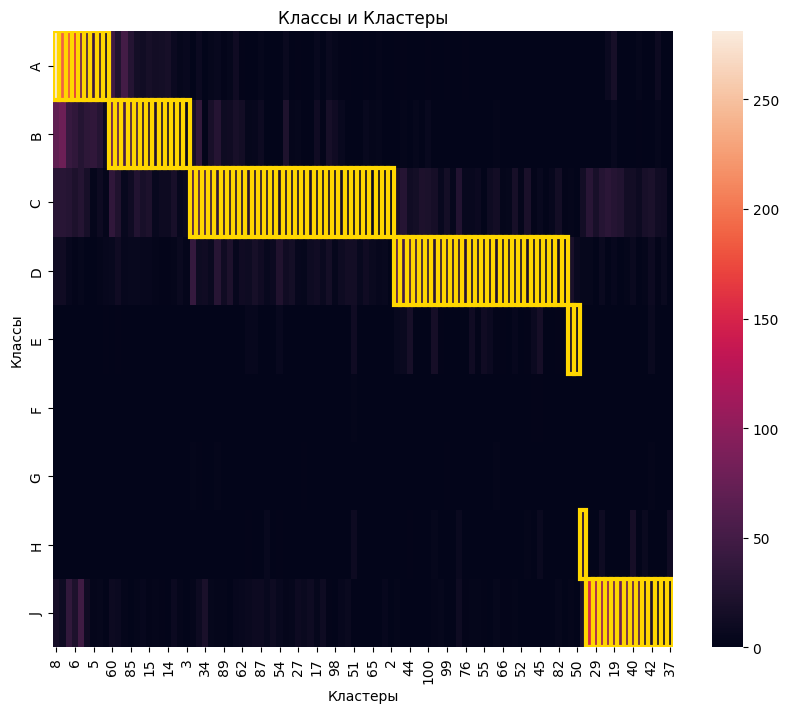

In [40]:
# Параметры для перебора

pca_n_components_list = [hier_df.iloc[0]['pca_n_components'].astype(int)]
num_clusters_list = [hier_df.iloc[0]['num_clusters']]
linkage_methods = [hier_df.iloc[0]['linkage']]
standardize_options = [hier_df.iloc[0]['standardize']]

# pca_n_components_list = [2]
# num_clusters_list = [15]
# linkage_methods = ['ward']
# standardize_options = [False]

for standardize in standardize_options:
    for linkage_method in linkage_methods:
        for n_components in pca_n_components_list:
            data = inv_emb.copy()
            
            # Стандартизация 
            if standardize:
                data = StandardScaler().fit_transform(data)
            else:
                data = data.values
            
            # PCA
            if n_components is not None:
                pca = PCA(n_components=n_components, random_state=0)
                inv_emb_pca = pca.fit_transform(data)
                df_inv_emb_pca = pd.DataFrame(inv_emb_pca, index=inv_emb.index)
            else:
                df_inv_emb_pca = pd.DataFrame(data, index=inv_emb.index)  # Используем оригинальные данные

            df_inv_emb_pca = df_inv_emb_pca.reset_index()
            
            # Кластеризация
            kmeans = KMeans(n_clusters=NUM, random_state=0, n_init='auto')
            labels_inv_vae = kmeans.fit_predict(df_inv_emb_pca.drop(columns='fname'))
            df_inv_emb_pca.columns = df_inv_emb_pca.columns.astype(str)

            for NUM in num_clusters_list:
                labels_inv_vae = fcluster(hier_clust, t=distances_sorted[NUM-1], criterion='distance')

                df_inv_emb_pca['cluster'] = labels_inv_vae

                # Соединение с изначальными метками
                link = pd.merge(zurich_class, df_inv_emb_pca, how='left', on='fname')
                link = link[['fname', 'Date', 'Time', 'Latitude', 'Longitude', 'Type', 'cluster']]

                # Crosstab
                crosstab = pd.crosstab(link['Type'], link['cluster'])

                if crosstab.shape[0] == 0 or crosstab.shape[1] == 0:
                    continue  # пропуск пустых таблиц

                # Изменяем порядок кластеров
                max_values = crosstab.max()
                max_indices = crosstab.idxmax()
                max_col = pd.DataFrame({
                    'max_values': max_values,
                    'max_indices': max_indices
                })
                max_col = max_col.sort_values(by=['max_indices', 'max_values'], ascending=[True, False]).reset_index()
                crosstab = crosstab[max_col['cluster']]
                
plt.figure(figsize=(10, 8))
ax = sns.heatmap(crosstab, annot=False, fmt='d', cbar=True)

#  отмечаем максимальные значения
for idx, row in max_col.iterrows():
    type_idx = list(crosstab.index).index(row['max_indices'])
    cluster_idx = list(crosstab.columns).index(row['cluster']) 
    ax.add_patch(plt.Rectangle((cluster_idx, type_idx), 1, 1, fill=False, edgecolor='gold', lw=3))


plt.title('Классы и Кластеры')
plt.xlabel('Кластеры')
plt.ylabel('Классы')
plt.show()


# **DBSCAN (в работе не используется)**

In [12]:
# Параметры
n_components_list = [2, 3, 4, 5, 10, 20]
eps_list = [0.3, 0.5, 0.7, 1.0]
min_samples_list = [3, 5, 10]
standardize_options = [True, False]

results = []

for standardize in standardize_options:
    for n_components in n_components_list:
        # PCA
        pca = PCA(n_components=n_components, random_state=0)
        data = inv_emb.copy()

        # Стандартизация
        if standardize:
            data = StandardScaler().fit_transform(data)
        else:
            data = data.values

        inv_emb_pca = pca.fit_transform(data)
        columns = [f'PC{i+1}' for i in range(inv_emb_pca.shape[1])]
        df_inv_emb_pca = pd.DataFrame(inv_emb_pca, index=inv_emb.index, columns=columns)
        df_inv_emb_pca = df_inv_emb_pca.reset_index()

        for eps in eps_list:
            for min_samples in min_samples_list:
                # DBSCAN
                X = df_inv_emb_pca.drop(columns='fname')
                X.columns = X.columns.astype(str)  # исправление ошибки типов

                dbscan = DBSCAN(eps=eps, min_samples=min_samples)
                labels_inv_vae = dbscan.fit_predict(X)

                df_inv_emb_pca['cluster'] = labels_inv_vae
                link = pd.merge(zurich_class, df_inv_emb_pca, how='left', on='fname')
                link = link[['fname', 'Date', 'Time', 'Latitude', 'Longitude', 'Type', 'cluster']]

                # Удаляем шумовые точки (label == -1)
                link = link[link['cluster'] != -1]
                if link.empty:
                    continue

                crosstab = pd.crosstab(link['Type'], link['cluster'])
                if crosstab.shape[0] == 0 or crosstab.shape[1] == 0:
                    continue

                # Assignment (type ↔ cluster)
                cost_matrix = -crosstab.values
                row_ind, col_ind = linear_sum_assignment(cost_matrix)

                type_to_cluster = {
                    crosstab.index[r]: crosstab.columns[c]
                    for r, c in zip(row_ind, col_ind)
                }

                # Метрики
                total = crosstab.values.sum()
                TP = sum(crosstab.loc[t, c] for t, c in type_to_cluster.items())
                accuracy = TP / 8498 #total

                precision, recall, f1_score = {}, {}, {}
                for t, c in type_to_cluster.items():
                    TP_i = crosstab.loc[t, c]
                    FP_i = crosstab[c].sum() - TP_i
                    FN_i = crosstab.loc[t].sum() - TP_i
                    precision[t] = TP_i / (TP_i + FP_i) if (TP_i + FP_i) > 0 else 0
                    recall[t] = TP_i / (TP_i + FN_i) if (TP_i + FN_i) > 0 else 0
                    f1_score[t] = (
                        2 * precision[t] * recall[t]
                    ) / (precision[t] + recall[t]) if (precision[t] + recall[t]) > 0 else 0

                avg_precision = np.mean(list(precision.values()))
                avg_recall = np.mean(list(recall.values()))
                avg_f1 = np.mean(list(f1_score.values()))

                results.append({
                    'clustering_method': 'dbscan',
                    'n_components': n_components,
                    'eps': eps,
                    'min_samples': min_samples,
                    'standardize': standardize,
                    'avg_precision': avg_precision,
                    'avg_recall': avg_recall,
                    'accuracy': accuracy,
                    'avg_f1_score': avg_f1,
                    'num_clusters': len(set(labels_inv_vae)) - (1 if -1 in labels_inv_vae else 0),
                    'num_noise': np.sum(labels_inv_vae == -1)
                })

# Сбор результатов
dbscan_df = pd.DataFrame(results)
dbscan_df = dbscan_df.sort_values(by='accuracy', ascending=False)
dbscan_df.to_csv('/kaggle/working/dbscan_inv_emb.csv',index=False)
dbscan_df


,clustering_method,n_components,eps,min_samples,standardize,avg_precision,avg_recall,accuracy,avg_f1_score,num_clusters,num_noise
33,dbscan,4,1.0,3,True,0.265115,0.208212,0.293363,0.189519,48,199
15,dbscan,3,0.5,3,True,0.357465,0.181058,0.289715,0.138497,74,303
34,dbscan,4,1.0,5,True,0.328358,0.240033,0.287244,0.223911,47,392
18,dbscan,3,0.7,3,True,0.339598,0.173767,0.285479,0.159278,78,147
19,dbscan,3,0.7,5,True,0.290674,0.171011,0.281949,0.150304,68,255
...,...,...,...,...,...,...,...,...,...,...,...
137,dbscan,20,0.5,10,False,0.193536,0.198156,0.012591,0.132115,20,7819
122,dbscan,10,0.3,10,False,0.193536,0.198156,0.012591,0.132115,20,7819
140,dbscan,20,0.7,10,False,0.193536,0.198156,0.012591,0.132115,20,7819
65,dbscan,20,0.5,10,True,0.193536,0.194101,0.012591,0.129937,22,7797


# **Gaussian Mixture Invariant embeddings**

In [4]:
# Параметры для перебора
pca_n_components_list = [False, 2, 3, 4, 5, 10, 20]
num_clusters_list = sorted(set([int(x) for x in np.logspace(np.log10(2), np.log10(100), num=50)]))
standardize_options = [True, False]

# pca_n_components_list = [2]
# num_clusters_list = [15]
# standardize_options = [False]

results = []

for standardize in standardize_options:
    for n_components in tqdm(pca_n_components_list, desc='PCA Components', leave=False):
        data = inv_emb.copy()
        
        # Стандартизация 
        if standardize:
            data = StandardScaler().fit_transform(data)
        else:
            data = data.values
        
        # PCA
        if n_components is not False:
            pca = PCA(n_components=n_components, random_state=0)
            inv_emb_pca = pca.fit_transform(data)
            df_inv_emb_pca = pd.DataFrame(inv_emb_pca, index=inv_emb.index)
        else:
            df_inv_emb_pca = pd.DataFrame(data, index=inv_emb.index)  # Используем оригинальные данные

        df_inv_emb_pca = df_inv_emb_pca.reset_index()
        
        for NUM in num_clusters_list:
            # Кластеризация с использованием GMM
            gmm = GaussianMixture(n_components=NUM, random_state=0)
            labels_inv_vae = gmm.fit_predict(df_inv_emb_pca.drop(columns='fname'))
            df_inv_emb_pca.columns = df_inv_emb_pca.columns.astype(str)
            df_inv_emb_pca['cluster'] = labels_inv_vae

            # Соединение с изначальными метками
            link = pd.merge(zurich_class, df_inv_emb_pca, how='left', on='fname')
            link = link[['fname', 'Date', 'Time', 'Latitude', 'Longitude', 'Type', 'cluster']]

            # Crosstab
            crosstab = pd.crosstab(link['Type'], link['cluster'])

            if crosstab.shape[0] == 0 or crosstab.shape[1] == 0:
                continue  # пропуск пустых таблиц

            # Изменяем порядок кластеров
            max_values = crosstab.max()
            max_indices = crosstab.idxmax()
            max_col = pd.DataFrame({
                'max_values': max_values,
                'max_indices': max_indices
            })
            max_col = max_col.sort_values(by=['max_indices', 'max_values'], ascending=[True, False]).reset_index()
            crosstab = crosstab[max_col['cluster']]

            # accuracy Type
            type_tp = max_col.groupby('max_indices')['max_values'].sum().reset_index(name='sum_max_values')
            type_total = crosstab.sum(axis=1).reset_index(name='sum_values')
            type_acc = pd.merge(type_total, type_tp, how='left', left_on='Type',right_on='max_indices') 
            type_acc.loc[type_acc['max_indices'].isna(), 'sum_max_values'] = 0
            type_acc['Accuracy'] = (type_acc['sum_max_values'] / type_acc['sum_values'])

            # Метрики
            total = crosstab.values.sum()
            sum_cluster_values = max_col['max_values'].sum()
            accuracy = sum_cluster_values / total

            results.append({
                'clustering_method': 'gmm',
                'pca_n_components': n_components,
                'num_clusters': NUM,
                'standardize': standardize,
                'sum_cluster_values': sum_cluster_values,
                'all_cluster_values': total,
                'accuracy_total': accuracy,
                'accuracy_Type_A': type_acc[type_acc['Type']=='A']['Accuracy'][0],
                'accuracy_Type_B': type_acc[type_acc['Type']=='B']['Accuracy'][1],
                'accuracy_Type_C': type_acc[type_acc['Type']=='C']['Accuracy'][2],
                'accuracy_Type_D': type_acc[type_acc['Type']=='D']['Accuracy'][3],
                'accuracy_Type_E': type_acc[type_acc['Type']=='E']['Accuracy'][4],
                'accuracy_Type_F': type_acc[type_acc['Type']=='F']['Accuracy'][5],
                'accuracy_Type_G': type_acc[type_acc['Type']=='G']['Accuracy'][6],
                'accuracy_Type_H': type_acc[type_acc['Type']=='H']['Accuracy'][7],
                'accuracy_Type_J': type_acc[type_acc['Type']=='J']['Accuracy'][8]
            })

gmm_df = pd.DataFrame(results)
gmm_df = gmm_df.sort_values(by='accuracy_total', ascending=False)

gmm_df.to_csv('/kaggle/working/gmm_inv_emb.csv', index=False)
gmm_df

,clustering_method,pca_n_components,num_clusters,standardize,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
293,gmm,False,85,False,4109,7520,0.546410,0.738621,0.437336,0.407969,0.620915,0.118812,0.0,0.0,0.343284,0.639049
443,gmm,5,100,False,4106,7520,0.546011,0.715862,0.414549,0.450056,0.603486,0.287129,0.0,0.0,0.231343,0.628963
294,gmm,False,92,False,4106,7520,0.546011,0.693793,0.483786,0.450056,0.554103,0.207921,0.0,0.0,0.320896,0.646974
295,gmm,False,100,False,4103,7520,0.545612,0.716552,0.440841,0.435466,0.607843,0.138614,0.0,0.0,0.171642,0.646254
480,gmm,10,100,False,4100,7520,0.545213,0.726897,0.409290,0.451740,0.568627,0.148515,0.0,0.0,0.216418,0.671470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,gmm,False,2,False,2482,7520,0.330053,0.565517,0.000000,0.932660,0.000000,0.000000,0.0,0.0,0.000000,0.000000
185,gmm,10,2,True,2461,7520,0.327261,0.545517,0.000000,0.937149,0.000000,0.000000,0.0,0.0,0.000000,0.000000
444,gmm,10,2,False,2454,7520,0.326330,0.538621,0.000000,0.938833,0.000000,0.000000,0.0,0.0,0.000000,0.000000
481,gmm,20,2,False,2427,7520,0.322739,0.513103,0.000000,0.944444,0.000000,0.000000,0.0,0.0,0.000000,0.000000


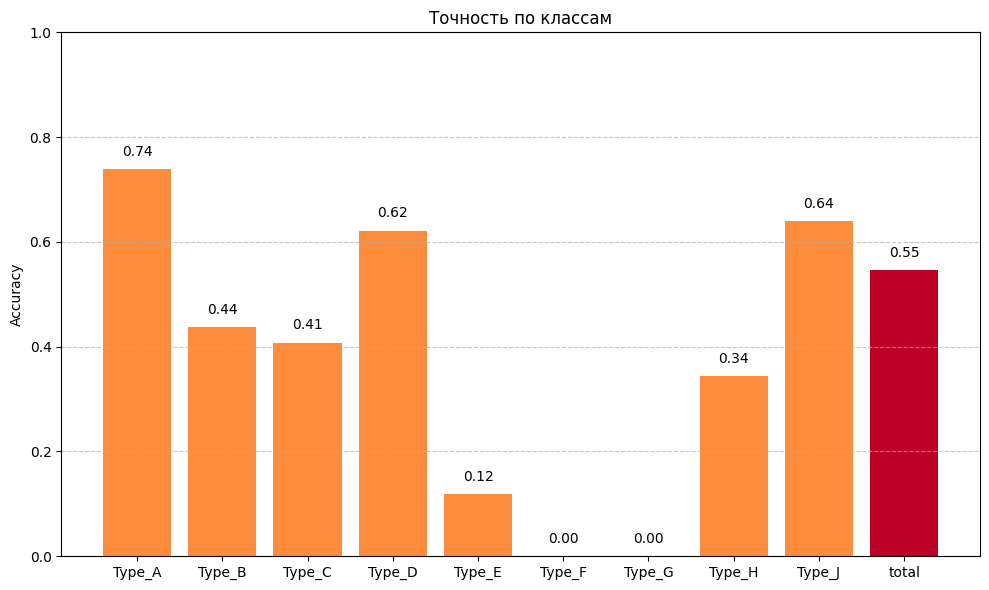

In [38]:
gmm_inv_vae = pd.read_csv('/kaggle/input/gmm-inv-emb/gmm_inv_emb.csv')

cols_to_plot = [
    'accuracy_Type_A', 'accuracy_Type_B', 'accuracy_Type_C', 'accuracy_Type_D',
    'accuracy_Type_E', 'accuracy_Type_F', 'accuracy_Type_G', 'accuracy_Type_H',
    'accuracy_Type_J', 'accuracy_total'
]

row = gmm_inv_vae.iloc[0]
values = [row[col] for col in cols_to_plot]
labels = [col.replace('accuracy_', '') for col in cols_to_plot]

# Построение столбчатой диаграммы
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#FD8D3C' if label != 'total' else '#BD0026' for label in labels])
plt.title("Точность по классам")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **VAE embeddings**

In [3]:
vae_emb = pd.read_csv('/kaggle/input/vae-sunspots-embeddings-4096-features/vae_sunspots_embeddings_4096_features.csv')
vae_emb = vae_emb.rename(columns={'Unnamed: 0':'fname'})
vae_emb = vae_emb.set_index('fname').sort_index()
vae_emb.head()

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
fname,,,,,,,,,,,,,,,,,,,,,
201007230452_63,-0.020374,-0.01979,-0.027678,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,...,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.015732,0.014741
201007240414_63,-0.020374,-0.01979,-0.027678,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,...,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.015732,0.014741
201007250447_63,-0.020374,-0.01979,-0.027678,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,...,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.015732,0.014741
201007250447_64,-0.020374,-0.01979,-0.027678,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,...,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.015732,0.014741
201007260349_63,-0.020374,-0.01979,-0.027678,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,-0.026606,...,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.016232,0.015732,0.014741


# **Иерархическая кластеризация**

In [6]:
# Параметры для перебора
pca_n_components_list = [False, 2, 3, 4, 5, 10, 20]
num_clusters_list = sorted(set([int(x) for x in np.logspace(np.log10(2), np.log10(100), num=50)]))
linkage_methods = ['ward', 'average', 'complete','single','weighted','centroid','median']
standardize_options = [True, False]

# pca_n_components_list = [2]
# num_clusters_list = [15]
# linkage_methods = ['ward']
# standardize_options = [False]

results = []

for standardize in standardize_options:
    for linkage_method in tqdm(linkage_methods, desc='Linkage Methods', leave=False):
        for n_components in tqdm(pca_n_components_list, desc='PCA Components', leave=False):
            data = vae_emb.copy()
            
            # Стандартизация 
            if standardize:
                data = StandardScaler().fit_transform(data)
            else:
                data = data.values
            
            # PCA
            if n_components is not False:
                pca = PCA(n_components=n_components, random_state=0)
                vae_emb_pca = pca.fit_transform(data)
                df_vae_emb_pca = pd.DataFrame(vae_emb_pca, index=vae_emb.index)
            else:
                df_vae_emb_pca = pd.DataFrame(data, index=vae_emb.index)  # Используем оригинальные данные

            df_vae_emb_pca = df_vae_emb_pca.reset_index()
            
            # Кластеризация
            hier_clust = linkage(df_vae_emb_pca.drop(columns='fname'), method=linkage_method)
            distances = hier_clust[-1000:, 2]
            distances_sorted = sorted(distances, reverse=True)

            for NUM in num_clusters_list:

                labels_inv_vae = fcluster(hier_clust, t=distances_sorted[NUM-1], criterion='distance')

                df_vae_emb_pca['cluster'] = labels_inv_vae

                # Соединение с изначальными метками
                link = pd.merge(zurich_class, df_vae_emb_pca, how='left', on='fname')
                link = link[['fname', 'Date', 'Time', 'Latitude', 'Longitude', 'Type', 'cluster']]

                # Crosstab
                crosstab = pd.crosstab(link['Type'], link['cluster'])

                if crosstab.shape[0] == 0 or crosstab.shape[1] == 0:
                    continue  # пропуск пустых таблиц

                # Изменяем порядок кластеров
                max_values = crosstab.max()
                max_indices = crosstab.idxmax()
                max_col = pd.DataFrame({
                    'max_values': max_values,
                    'max_indices': max_indices
                })
                max_col = max_col.sort_values(by=['max_indices', 'max_values'], ascending=[True, False]).reset_index()
                crosstab = crosstab[max_col['cluster']]

                # accuracy Type
                type_tp = max_col.groupby('max_indices')['max_values'].sum().reset_index(name='sum_max_values')
                type_total = crosstab.sum(axis=1).reset_index(name='sum_values')
                type_acc = pd.merge(type_total, type_tp, how='left', left_on='Type',right_on='max_indices') 
                type_acc.loc[type_acc['max_indices'].isna(), 'sum_max_values'] = 0
                type_acc['Accuracy'] = (type_acc['sum_max_values'] / type_acc['sum_values'])

                # Переименовываем столбцы, начиная с 1
                # new_cluster_names = {old_name: f'{i+1}' for i, old_name in enumerate(max_col['cluster'])}
                # crosstab.rename(columns=new_cluster_names, inplace=True)

                # Метрики
                total = crosstab.values.sum()
                sum_cluster_values =  max_col['max_values'].sum()
                accuracy = sum_cluster_values / total

                results.append({
                    'clustering_method': 'hier_clust',
                    'pca_n_components': n_components,
                    'num_clusters': NUM,
                    'linkage': linkage_method,
                    'standardize': standardize,
                    'sum_cluster_values': sum_cluster_values,
                    'all_cluster_values': total,
                    'accuracy_total': accuracy,
                    'accuracy_Type_A': type_acc[type_acc['Type']=='A']['Accuracy'][0],
                    'accuracy_Type_B': type_acc[type_acc['Type']=='B']['Accuracy'][1],
                    'accuracy_Type_C': type_acc[type_acc['Type']=='C']['Accuracy'][2],
                    'accuracy_Type_D': type_acc[type_acc['Type']=='D']['Accuracy'][3],
                    'accuracy_Type_E': type_acc[type_acc['Type']=='E']['Accuracy'][4],
                    'accuracy_Type_F': type_acc[type_acc['Type']=='F']['Accuracy'][5],
                    'accuracy_Type_G': type_acc[type_acc['Type']=='G']['Accuracy'][6],
                    'accuracy_Type_H': type_acc[type_acc['Type']=='H']['Accuracy'][7],
                    'accuracy_Type_J': type_acc[type_acc['Type']=='J']['Accuracy'][8]
                })

hier_df = pd.DataFrame(results)
hier_df = hier_df.sort_values(by='accuracy_total', ascending=False)

hier_df.to_csv('/kaggle/working/hier_vae_emb.csv',index=False)
hier_df 

PCA Components: 100%|██████████| 7/7 [02:39<00:00, 10.94s/it]


,clustering_method,pca_n_components,num_clusters,linkage,standardize,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
2034,hier_clust,10,100,ward,False,4086,7520,0.543351,0.613103,0.521472,0.455668,0.575163,0.217822,0.0,0.0,0.194030,0.668588
2033,hier_clust,10,92,ward,False,4061,7520,0.540027,0.613103,0.521472,0.460157,0.560639,0.217822,0.0,0.0,0.149254,0.663545
2032,hier_clust,10,85,ward,False,4050,7520,0.538564,0.613103,0.521472,0.464085,0.547567,0.217822,0.0,0.0,0.149254,0.663545
2031,hier_clust,10,78,ward,False,4040,7520,0.537234,0.613103,0.521472,0.448373,0.560639,0.217822,0.0,0.0,0.149254,0.663545
1960,hier_clust,4,100,ward,False,4035,7520,0.536569,0.651724,0.573181,0.428171,0.537400,0.173267,0.0,0.0,0.328358,0.615274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3367,hier_clust,False,2,median,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
2627,hier_clust,2,2,single,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
3108,hier_clust,False,2,centroid,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
2072,hier_clust,False,2,average,False,1782,7520,0.236968,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000


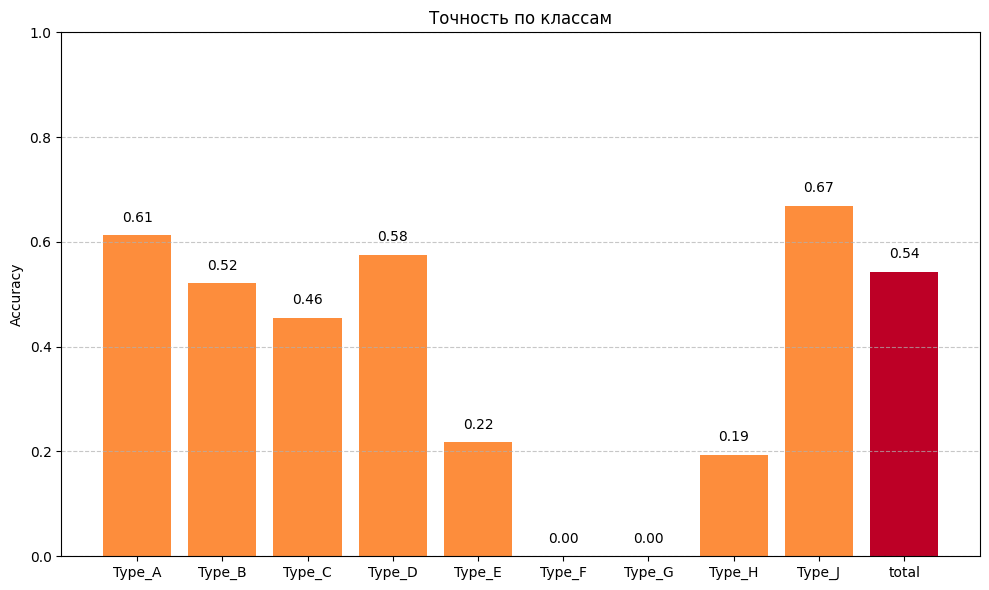

In [37]:
hier_vae_df = pd.read_csv('/kaggle/input/hier-vae-emb/hier_vae_emb.csv')

cols_to_plot = [
    'accuracy_Type_A', 'accuracy_Type_B', 'accuracy_Type_C', 'accuracy_Type_D',
    'accuracy_Type_E', 'accuracy_Type_F', 'accuracy_Type_G', 'accuracy_Type_H',
    'accuracy_Type_J', 'accuracy_total'
]

row = hier_vae_df.iloc[0]
values = [row[col] for col in cols_to_plot]
labels = [col.replace('accuracy_', '') for col in cols_to_plot]

# Построение столбчатой диаграммы
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#FD8D3C' if label != 'total' else '#BD0026' for label in labels])
plt.title("Точность по классам")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **KMeans**

In [7]:
# Параметры для перебора
pca_n_components_list = [False, 2, 3, 4, 5, 10, 20]
num_clusters_list = sorted(set([int(x) for x in np.logspace(np.log10(2), np.log10(100), num=50)]))
linkage_methods = ['ward', 'average', 'complete','single','weighted','centroid','median']
standardize_options = [True, False]

# pca_n_components_list = [2]
# num_clusters_list = [15]
# linkage_methods = ['ward']
# standardize_options = [False]

results = []

for standardize in standardize_options:
    for n_components in tqdm(pca_n_components_list, desc='PCA Components', leave=False):
        data = vae_emb.copy()  # Изменено на vae_emb
        
        # Стандартизация 
        if standardize:
            data = StandardScaler().fit_transform(data)
        else:
            data = data.values
        
        # PCA
        if n_components is not False:
            pca = PCA(n_components=n_components, random_state=0)
            vae_emb_pca = pca.fit_transform(data)  # Изменено на vae_emb_pca
            df_vae_emb_pca = pd.DataFrame(vae_emb_pca, index=vae_emb.index)  # Изменено на vae_emb
        else:
            df_vae_emb_pca = pd.DataFrame(data, index=vae_emb.index)  # Используем оригинальные данные
        df_vae_emb_pca = df_vae_emb_pca.reset_index()
        
        # Кластеризация
        kmeans = KMeans(n_clusters=NUM, random_state=0, n_init='auto')
        labels_vae = kmeans.fit_predict(df_vae_emb_pca.drop(columns='fname'))  # Изменено на labels_vae
        df_vae_emb_pca.columns = df_vae_emb_pca.columns.astype(str)
        for NUM in num_clusters_list:
            labels_vae = fcluster(hier_clust, t=distances_sorted[NUM-1], criterion='distance')
            df_vae_emb_pca['cluster'] = labels_vae
            # Соединение с изначальными метками
            link = pd.merge(zurich_class, df_vae_emb_pca, how='left', on='fname')
            link = link[['fname', 'Date', 'Time', 'Latitude', 'Longitude', 'Type', 'cluster']]
            # Crosstab
            crosstab = pd.crosstab(link['Type'], link['cluster'])
            if crosstab.shape[0] == 0 or crosstab.shape[1] == 0:
                continue  # пропуск пустых таблиц
            # Изменяем порядок кластеров
            max_values = crosstab.max()
            max_indices = crosstab.idxmax()
            max_col = pd.DataFrame({
                'max_values': max_values,
                'max_indices': max_indices
            })
            max_col = max_col.sort_values(by=['max_indices', 'max_values'], ascending=[True, False]).reset_index()
            crosstab = crosstab[max_col['cluster']]

            # accuracy Type
            type_tp = max_col.groupby('max_indices')['max_values'].sum().reset_index(name='sum_max_values')
            type_total = crosstab.sum(axis=1).reset_index(name='sum_values')
            type_acc = pd.merge(type_total, type_tp, how='left', left_on='Type',right_on='max_indices') 
            type_acc.loc[type_acc['max_indices'].isna(), 'sum_max_values'] = 0
            type_acc['Accuracy'] = (type_acc['sum_max_values'] / type_acc['sum_values'])
            
            # Метрики
            total = crosstab.values.sum()
            sum_cluster_values = max_col['max_values'].sum()
            accuracy = sum_cluster_values / total
            results.append({
                'clustering_method': 'kmeans',
                'pca_n_components': n_components,
                'num_clusters': NUM,
                'standardize': standardize,
                'sum_cluster_values': sum_cluster_values,
                'all_cluster_values': total,
                'accuracy_total': accuracy,
                'accuracy_Type_A': type_acc[type_acc['Type']=='A']['Accuracy'][0],
                'accuracy_Type_B': type_acc[type_acc['Type']=='B']['Accuracy'][1],
                'accuracy_Type_C': type_acc[type_acc['Type']=='C']['Accuracy'][2],
                'accuracy_Type_D': type_acc[type_acc['Type']=='D']['Accuracy'][3],
                'accuracy_Type_E': type_acc[type_acc['Type']=='E']['Accuracy'][4],
                'accuracy_Type_F': type_acc[type_acc['Type']=='F']['Accuracy'][5],
                'accuracy_Type_G': type_acc[type_acc['Type']=='G']['Accuracy'][6],
                'accuracy_Type_H': type_acc[type_acc['Type']=='H']['Accuracy'][7],
                'accuracy_Type_J': type_acc[type_acc['Type']=='J']['Accuracy'][8]
            })

kmeans_df = pd.DataFrame(results)
kmeans_df = kmeans_df.sort_values(by='accuracy_total', ascending=False)

kmeans_df.to_csv('/kaggle/working/kmeans_vae_emb.csv', index=False)  # Изменено на kmeans_vae_emb.csv
kmeans_df


,clustering_method,pca_n_components,num_clusters,standardize,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
517,kmeans,20,100,False,1992,7520,0.264894,0.00069,0.0,0.930415,0.201162,0.237624,0.333333,0.058824,0.0,0.001441
406,kmeans,4,100,False,1992,7520,0.264894,0.00069,0.0,0.930415,0.201162,0.237624,0.333333,0.058824,0.0,0.001441
73,kmeans,2,100,True,1992,7520,0.264894,0.00069,0.0,0.930415,0.201162,0.237624,0.333333,0.058824,0.0,0.001441
36,kmeans,False,100,True,1992,7520,0.264894,0.00069,0.0,0.930415,0.201162,0.237624,0.333333,0.058824,0.0,0.001441
332,kmeans,2,100,False,1992,7520,0.264894,0.00069,0.0,0.930415,0.201162,0.237624,0.333333,0.058824,0.0,0.001441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,kmeans,5,2,False,1782,7520,0.236968,0.00000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
408,kmeans,5,3,False,1782,7520,0.236968,0.00000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
444,kmeans,10,2,False,1782,7520,0.236968,0.00000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
445,kmeans,10,3,False,1782,7520,0.236968,0.00000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000


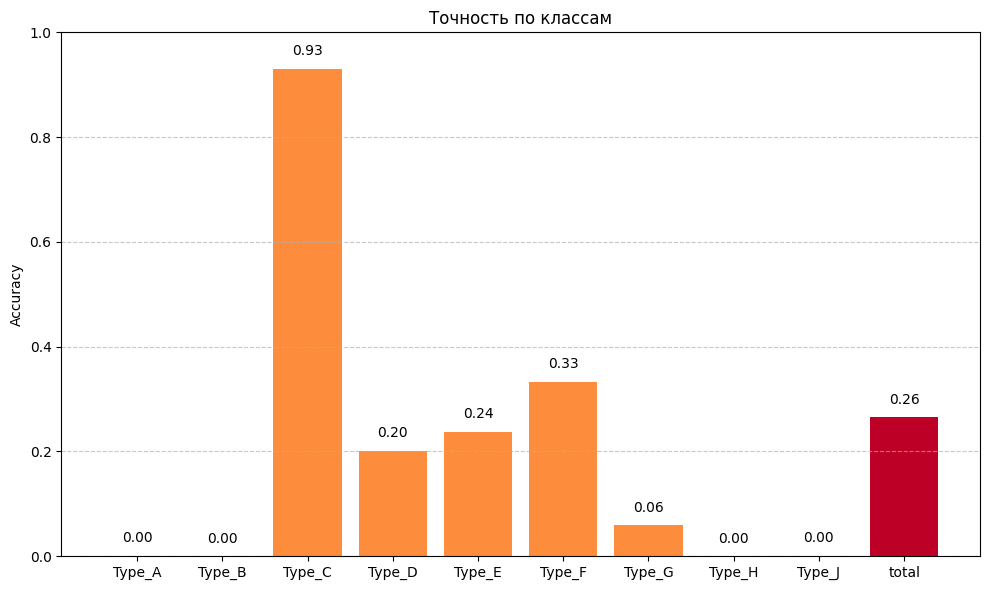

In [36]:
kmeans_vae_df = pd.read_csv('/kaggle/input/kmeans-vae-emb/kmeans_vae_emb.csv')

cols_to_plot = [
    'accuracy_Type_A', 'accuracy_Type_B', 'accuracy_Type_C', 'accuracy_Type_D',
    'accuracy_Type_E', 'accuracy_Type_F', 'accuracy_Type_G', 'accuracy_Type_H',
    'accuracy_Type_J', 'accuracy_total'
]

row = kmeans_vae_df.iloc[0]
values = [row[col] for col in cols_to_plot]
labels = [col.replace('accuracy_', '') for col in cols_to_plot]

# Построение столбчатой диаграммы
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#FD8D3C' if label != 'total' else '#BD0026' for label in labels])
plt.title("Точность по классам")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [44]:
kmeans_vae_df

,clustering_method,pca_n_components,num_clusters,standardize,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
0,kmeans,20,100,False,1992,7520,0.264894,0.00069,0.0,0.930415,0.201162,0.237624,0.333333,0.058824,0.0,0.001441
1,kmeans,4,100,False,1992,7520,0.264894,0.00069,0.0,0.930415,0.201162,0.237624,0.333333,0.058824,0.0,0.001441
2,kmeans,2,100,True,1992,7520,0.264894,0.00069,0.0,0.930415,0.201162,0.237624,0.333333,0.058824,0.0,0.001441
3,kmeans,False,100,True,1992,7520,0.264894,0.00069,0.0,0.930415,0.201162,0.237624,0.333333,0.058824,0.0,0.001441
4,kmeans,2,100,False,1992,7520,0.264894,0.00069,0.0,0.930415,0.201162,0.237624,0.333333,0.058824,0.0,0.001441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,kmeans,5,2,False,1782,7520,0.236968,0.00000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
514,kmeans,5,3,False,1782,7520,0.236968,0.00000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
515,kmeans,10,2,False,1782,7520,0.236968,0.00000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
516,kmeans,10,3,False,1782,7520,0.236968,0.00000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000


In [45]:
kmeans_vae_df.describe()

,num_clusters,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
count,518.000000,518.000000,518.0,518.000000,518.000000,518.0,518.000000,518.000000,518.000000,518.000000,518.000000,518.0,518.000000
mean,32.513514,1861.918919,7520.0,0.247596,0.000037,0.0,0.987108,0.061022,0.084694,0.110360,0.004769,0.0,0.000156
std,27.132222,58.787665,0.0,0.007818,0.000156,0.0,0.022229,0.056445,0.072258,0.098990,0.016072,0.0,0.000341
min,2.000000,1782.000000,7520.0,0.236968,0.000000,0.0,0.930415,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,11.000000,1794.000000,7520.0,0.238564,0.000000,0.0,0.997194,0.005810,0.019802,0.000000,0.000000,0.0,0.000000
50%,23.000000,1869.000000,7520.0,0.248537,0.000000,0.0,0.998878,0.054466,0.074257,0.166667,0.000000,0.0,0.000000
75%,48.000000,1882.000000,7520.0,0.250266,0.000000,0.0,0.999439,0.057371,0.108911,0.166667,0.000000,0.0,0.000000
max,100.000000,1992.000000,7520.0,0.264894,0.000690,0.0,1.000000,0.201162,0.237624,0.333333,0.058824,0.0,0.001441


# **Gaussian Mixture**

In [6]:
# Параметры для перебора
pca_n_components_list = [2, 3, 4, 5, 10, 20]
num_clusters_list = sorted(set([int(x) for x in np.logspace(np.log10(2), np.log10(100), num=50)]))
standardize_options = [True, False]

# pca_n_components_list = [2]
# num_clusters_list = [2]
# standardize_options = [True, False]

results = []

for standardize in standardize_options:
    for n_components in tqdm(pca_n_components_list, desc='PCA Components', leave=False):
        data = vae_emb.copy()  # Изменено на vae_emb
        
        # Стандартизация 
        if standardize:
            data = StandardScaler().fit_transform(data)
        else:
            data = data.values
        
        # PCA
        if n_components is not False:
            pca = PCA(n_components=n_components, random_state=0)
            vae_emb_pca = pca.fit_transform(data)  # Изменено на vae_emb_pca
            df_vae_emb_pca = pd.DataFrame(vae_emb_pca, index=vae_emb.index)  # Изменено на vae_emb
        else:
            df_vae_emb_pca = pd.DataFrame(data, index=vae_emb.index)  # Используем оригинальные данные

        df_vae_emb_pca = df_vae_emb_pca.reset_index()
        
        for NUM in num_clusters_list:
            # Кластеризация с использованием GMM
            gmm = GaussianMixture(n_components=NUM, random_state=0)
            labels_vae = gmm.fit_predict(df_vae_emb_pca.drop(columns='fname'))  # Изменено на labels_vae
            df_vae_emb_pca.columns = df_vae_emb_pca.columns.astype(str)
            df_vae_emb_pca['cluster'] = labels_vae

            # Соединение с изначальными метками
            link = pd.merge(zurich_class, df_vae_emb_pca, how='left', on='fname')
            link = link[['fname', 'Date', 'Time', 'Latitude', 'Longitude', 'Type', 'cluster']]

            # Crosstab
            crosstab = pd.crosstab(link['Type'], link['cluster'])

            if crosstab.shape[0] == 0 or crosstab.shape[1] == 0:
                continue  # пропуск пустых таблиц

            # Изменяем порядок кластеров
            max_values = crosstab.max()
            max_indices = crosstab.idxmax()
            max_col = pd.DataFrame({
                'max_values': max_values,
                'max_indices': max_indices
            })
            max_col = max_col.sort_values(by=['max_indices', 'max_values'], ascending=[True, False]).reset_index()
            crosstab = crosstab[max_col['cluster']]

            # accuracy Type
            type_tp = max_col.groupby('max_indices')['max_values'].sum().reset_index(name='sum_max_values')
            type_total = crosstab.sum(axis=1).reset_index(name='sum_values')
            type_acc = pd.merge(type_total, type_tp, how='left', left_on='Type',right_on='max_indices') 
            type_acc.loc[type_acc['max_indices'].isna(), 'sum_max_values'] = 0
            type_acc['Accuracy'] = (type_acc['sum_max_values'] / type_acc['sum_values'])

            # Метрики
            total = crosstab.values.sum()
            sum_cluster_values = max_col['max_values'].sum()
            accuracy = sum_cluster_values / total

            results.append({
                'clustering_method': 'gmm',
                'pca_n_components': n_components,
                'num_clusters': NUM,
                'standardize': standardize,
                'sum_cluster_values': sum_cluster_values,
                'all_cluster_values': total,
                'accuracy_total': accuracy,
                'accuracy_Type_A': type_acc[type_acc['Type']=='A']['Accuracy'][0],
                'accuracy_Type_B': type_acc[type_acc['Type']=='B']['Accuracy'][1],
                'accuracy_Type_C': type_acc[type_acc['Type']=='C']['Accuracy'][2],
                'accuracy_Type_D': type_acc[type_acc['Type']=='D']['Accuracy'][3],
                'accuracy_Type_E': type_acc[type_acc['Type']=='E']['Accuracy'][4],
                'accuracy_Type_F': type_acc[type_acc['Type']=='F']['Accuracy'][5],
                'accuracy_Type_G': type_acc[type_acc['Type']=='G']['Accuracy'][6],
                'accuracy_Type_H': type_acc[type_acc['Type']=='H']['Accuracy'][7],
                'accuracy_Type_J': type_acc[type_acc['Type']=='J']['Accuracy'][8]
            })

gmm_df = pd.DataFrame(results)
gmm_df = gmm_df.sort_values(by='accuracy_total', ascending=False)

gmm_df.to_csv('/kaggle/working/gmm_vae_emb.csv', index=False)  # Изменено на gmm_vae_emb.csv
gmm_df


,clustering_method,pca_n_components,num_clusters,standardize,sum_cluster_values,all_cluster_values,accuracy_total,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J
36,gmm,2,100,True,3903,7520,0.519016,0.715172,0.326030,0.471380,0.566449,0.356436,0.000000,0.029412,0.029851,0.574207
35,gmm,2,92,True,3900,7520,0.518617,0.715172,0.326030,0.458474,0.559913,0.341584,0.083333,0.029412,0.022388,0.597262
68,gmm,3,67,True,3896,7520,0.518085,0.735862,0.367222,0.442761,0.564270,0.242574,0.083333,0.000000,0.037313,0.568444
34,gmm,2,85,True,3896,7520,0.518085,0.715172,0.326030,0.456790,0.557734,0.351485,0.083333,0.029412,0.022388,0.597262
184,gmm,10,100,True,3891,7520,0.517420,0.525517,0.398773,0.494949,0.557734,0.410891,0.083333,0.000000,0.216418,0.656340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,gmm,2,6,True,2388,7520,0.317553,0.985517,0.000000,0.000000,0.672476,0.163366,0.000000,0.000000,0.000000,0.000000
2,gmm,2,4,True,2388,7520,0.317553,0.985517,0.000000,0.000000,0.672476,0.163366,0.000000,0.000000,0.000000,0.000000
1,gmm,2,3,True,2371,7520,0.315293,0.985517,0.000000,0.000000,0.684096,0.000000,0.000000,0.000000,0.000000,0.000000
0,gmm,2,2,True,2371,7520,0.315293,0.985517,0.000000,0.000000,0.684096,0.000000,0.000000,0.000000,0.000000,0.000000


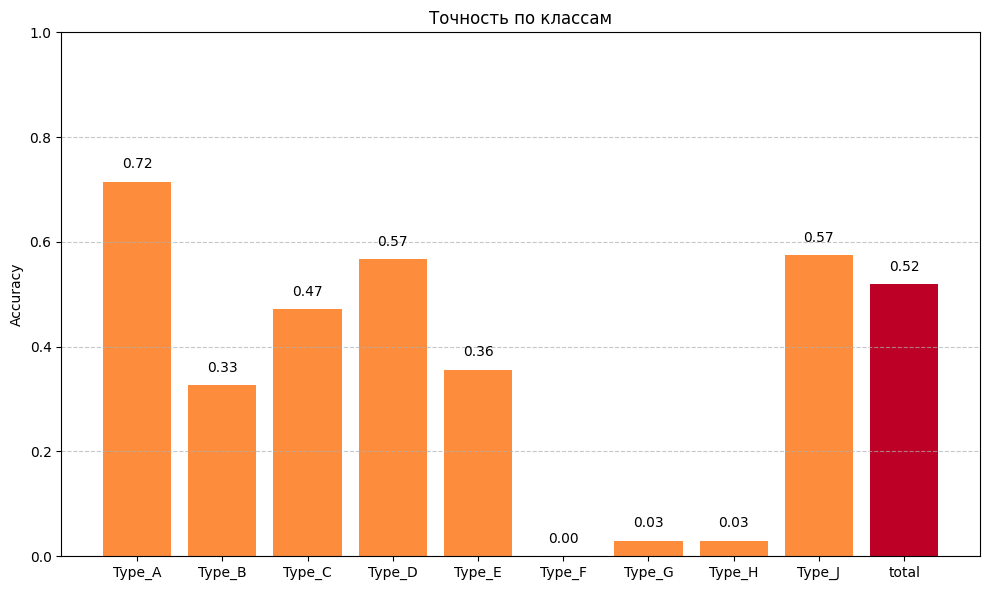

In [35]:
gmm_vae_df = pd.read_csv('/kaggle/input/gmm-vae-emb/gmm_vae_emb.csv')

cols_to_plot = [
    'accuracy_Type_A', 'accuracy_Type_B', 'accuracy_Type_C', 'accuracy_Type_D',
    'accuracy_Type_E', 'accuracy_Type_F', 'accuracy_Type_G', 'accuracy_Type_H',
    'accuracy_Type_J', 'accuracy_total'
]

row = gmm_vae_df.iloc[0]
values = [row[col] for col in cols_to_plot]
labels = [col.replace('accuracy_', '') for col in cols_to_plot]

# Построение столбчатой диаграммы
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#FD8D3C' if label != 'total' else '#BD0026' for label in labels])
plt.title("Точность по классам")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [49]:
gmm_vae_df[cols_to_plot].describe().iloc[1:]

,accuracy_Type_A,accuracy_Type_B,accuracy_Type_C,accuracy_Type_D,accuracy_Type_E,accuracy_Type_F,accuracy_Type_G,accuracy_Type_H,accuracy_Type_J,accuracy_total
mean,0.848304,0.097907,0.279569,0.579459,0.139996,0.026276,0.000596,0.085485,0.476507,0.444058
std,0.156693,0.211618,0.174049,0.102385,0.113590,0.056252,0.005003,0.121526,0.255858,0.064116
min,0.446207,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.315027
25%,0.735000,0.000000,0.155724,0.510530,0.004950,0.000000,0.000000,0.000000,0.454611,0.416257
50%,0.910345,0.000000,0.298822,0.589325,0.148515,0.000000,0.000000,0.014925,0.597262,0.466090
75%,0.964828,0.000876,0.419613,0.633987,0.212871,0.000000,0.000000,0.216418,0.643372,0.495080
max,0.990345,0.705521,0.643659,0.778504,0.435644,0.416667,0.058824,0.380597,0.755043,0.519016
